# Математика для программирования часть (2/2)

## Раздел дискриминативного ИИ

### Блок предварительной обработки данных

#### pandas - для работы с табличными данными и их первичной обработки и трансформации
#### numpy - для работы с векторными данными (в настоящем проекте чаще всего применяется для трансформации и представления данных для графиков (библиотеки matplotlib и yellowbrick)
#### matplotlib - для различных типов графиков
#### seaborn - графики мат. зависимостей
#### sklearn (scikit-learn) - для моделей машинного обучения
#### itertools - набор функций для создания и управления итераторами (в данном проекте помогает реализовать множество визуализаций на одном графике)

In [1]:
import pandas as pd # для работы с dataframe
import numpy as np# для работы с числовыми данными и вычислениями
import matplotlib.pyplot as plt # для создания графиков 
import matplotlib.cm as cm # для работы с цветами
from sklearn.impute import SimpleImputer # класс для заполнения пустых ячеек в датасете(средним по столцу например)
from sklearn.compose import ColumnTransformer # для рпеобразования столцов по типу данных в нем
from sklearn.preprocessing import StandardScaler, OneHotEncoder # масштабатор данных и стандартизации данных
from sklearn.decomposition import PCA #метод главных компонент для понижения размерности
from yellowbrick.cluster import KElbowVisualizer, silhouette_visualizer, SilhouetteVisualizer#
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering#
from sklearn.ensemble import RandomForestClassifier#
from sklearn.metrics import silhouette_samples, silhouette_score#
from sklearn.neighbors import NearestNeighbors # модуль для алогоритма посика ближайщих соседних точек к данной
import seaborn as sns #мат. графики
import itertools #для итераций по сложным структурам
import warnings
import os
warnings.filterwarnings('ignore')

#### Базовая работа с табличными данными начинается с загрузки самих данных из набора или извлечения их из таблиц баз данных посредством запросов
#### Для того, чтобы удостовериться в корректности и полноте загрузки данных выводят информацию о сформированном датафрейме и его первые 5 записей

In [2]:
#------ набор данных с основной информацией о сотрудниках и их призводительности
df = pd.read_csv('employees_data.csv')  # или pd.read_excel('employee_data.xlsx')
df.info() #вывод информации о датафрейме
df.head() #вывод первых 5 строк датафрейма

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         1000 non-null   int64  
 1   age                 954 non-null    float64
 2   salary              960 non-null    float64
 3   years_experience    939 non-null    float64
 4   performance_score   945 non-null    float64
 5   hours_per_week      949 non-null    float64
 6   department          1000 non-null   object 
 7   education_level     1000 non-null   object 
 8   remote_work         1000 non-null   object 
 9   satisfaction_score  951 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 78.3+ KB


,employee_id,age,salary,years_experience,performance_score,hours_per_week,department,education_level,remote_work,satisfaction_score
0,1,39.967142,87987.108732,4.624109,1.973754,33.092051,IT,Master,No,2.975171
1,2,33.617357,78492.673658,7.277407,2.811692,39.750372,Finance,PhD,Yes,4.198670
2,3,41.476885,61192.607398,4.037900,3.169116,40.144135,Marketing,PhD,Yes,2.746532
3,4,50.230299,47061.264446,6.460192,5.010150,43.781043,Finance,Bachelor,No,3.104940
4,5,32.658466,73964.466272,-1.468073,3.945242,29.065133,HR,Bachelor,Yes,4.985257


#### Найти дублирующиеся строки, так как они не несут в себе каких-либо дополнительных полезных признаков, зато занимают место в памяти и лишний раз подаётся в модель

In [3]:
df_cleaned = df.drop('employee_id', axis=1) #удаление столбца с уникальным идентификатором
df_cleaned = df_cleaned.drop_duplicates() #как и dropna поддерживает параметр subset
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 954 non-null    float64
 1   salary              960 non-null    float64
 2   years_experience    939 non-null    float64
 3   performance_score   945 non-null    float64
 4   hours_per_week      949 non-null    float64
 5   department          1000 non-null   object 
 6   education_level     1000 non-null   object 
 7   remote_work         1000 non-null   object 
 8   satisfaction_score  951 non-null    float64
dtypes: float64(6), object(3)
memory usage: 70.4+ KB


#### Одним из <b>первых и главных действий</b> при предобработке данных является <u>очистка набора от отсутствующих записей (NaN)</u>, такие строки либо просто удалются, либо пропущенные значения заменяются значениями, полученными с помощью математических методов (чаще всего - статистическими) 

In [4]:
df_cleaned = df_cleaned.dropna(how='all') #удаление строк, где пропущены все значения
df_cleaned = df_cleaned.dropna(thresh=len(df.columns) - 2) #полное удаление строк, где более 2 пропусков
df_cleaned= df_cleaned.dropna(subset=['performance_score', 'hours_per_week', 'satisfaction_score', 'salary']) #удаление строк с пропуском хотя бы одном из перечислееных столбцов
df_cleaned.info()
df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
Index: 870 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 863 non-null    float64
 1   salary              870 non-null    float64
 2   years_experience    857 non-null    float64
 3   performance_score   870 non-null    float64
 4   hours_per_week      870 non-null    float64
 5   department          870 non-null    object 
 6   education_level     870 non-null    object 
 7   remote_work         870 non-null    object 
 8   satisfaction_score  870 non-null    float64
dtypes: float64(6), object(3)
memory usage: 68.0+ KB


,age,salary,years_experience,performance_score,hours_per_week,department,education_level,remote_work,satisfaction_score
0,39.967142,87987.108732,4.624109,1.973754,33.092051,IT,Master,No,2.975171
1,33.617357,78492.673658,7.277407,2.811692,39.750372,Finance,PhD,Yes,4.198670
2,41.476885,61192.607398,4.037900,3.169116,40.144135,Marketing,PhD,Yes,2.746532
3,50.230299,47061.264446,6.460192,5.010150,43.781043,Finance,Bachelor,No,3.104940
4,32.658466,73964.466272,-1.468073,3.945242,29.065133,HR,Bachelor,Yes,4.985257


#### Необходимо проанализировать, есть ли среди основных колонок отрицательные значения, так как они и так являются для них шумом в данной задаче, для чего можно вывести минимальные значения по нужным столбцам

In [5]:
print(df_cleaned['years_experience'].min(), df_cleaned['performance_score'].min(), df_cleaned['hours_per_week'].min(), df_cleaned['satisfaction_score'].min(), df_cleaned['salary'].min())

-6.955679854503616 1.1564410479981857 14.586369494431995 0.3852853005081869 1192.227306714398


#### Наиболее вероятно, что отрицательный опыт работы - это просто ошибка ввода, при которой знак тире попал в строчку, поэтому достаточно заменить такие отрицательные значения абсолютным по модулю 

In [6]:
df_cleaned.loc[df_cleaned['years_experience'] < 0, 'years_experience'] = df_cleaned.loc[df_cleaned['years_experience'] < 0, 'years_experience'].abs() #замена строчек в отрицательным опытом работы абсолютным значением
df_cleaned.info()
df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
Index: 870 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 863 non-null    float64
 1   salary              870 non-null    float64
 2   years_experience    857 non-null    float64
 3   performance_score   870 non-null    float64
 4   hours_per_week      870 non-null    float64
 5   department          870 non-null    object 
 6   education_level     870 non-null    object 
 7   remote_work         870 non-null    object 
 8   satisfaction_score  870 non-null    float64
dtypes: float64(6), object(3)
memory usage: 68.0+ KB


,age,salary,years_experience,performance_score,hours_per_week,department,education_level,remote_work,satisfaction_score
0,39.967142,87987.108732,4.624109,1.973754,33.092051,IT,Master,No,2.975171
1,33.617357,78492.673658,7.277407,2.811692,39.750372,Finance,PhD,Yes,4.198670
2,41.476885,61192.607398,4.037900,3.169116,40.144135,Marketing,PhD,Yes,2.746532
3,50.230299,47061.264446,6.460192,5.010150,43.781043,Finance,Bachelor,No,3.104940
4,32.658466,73964.466272,1.468073,3.945242,29.065133,HR,Bachelor,Yes,4.985257


#### Разбиение данных на категориальные и числовые позволяет упростить дальнейшую работу с данными, а также позволяет применять для признаков каждого из типов конкретные операции, так как числовые значения редко повторяются, но имеют некоторые среднии показатели, а категориальные обычно как раз имеют модальные значения, т.к. количество уникальных значений категориальных признаков ограничено

In [7]:
cat_cols = df_cleaned.select_dtypes(include=['object']).columns #выбор колонок с категориальными данными
num_cols = df_cleaned.select_dtypes(include=['float64']).columns #выбор колонок с числовыми данными
row_indices = df_cleaned[num_cols].isna().any(axis=1) # подсвечивает сроки где есть пропуски
row_numbers = df_cleaned.index[row_indices].tolist()
print(row_numbers)  # Вывести индексы строк с NaN в числовых полях
df_nan_rows = df_cleaned.loc[row_numbers]
print(df_nan_rows)
print(row_indices)

[22, 53, 69, 124, 206, 246, 334, 424, 458, 545, 570, 600, 623, 648, 704, 705, 752, 817, 910, 994]
            age         salary  years_experience  performance_score  \
22    35.675282   59512.908155               NaN           3.170859   
53    41.116763   65213.475316               NaN           2.872997   
69    28.548802   66930.077635               NaN           4.054178   
124         NaN   92668.630646          8.112329           3.388482   
206   40.150353   45960.166244               NaN           2.881872   
246         NaN   60681.669365          3.506080           3.853046   
334   44.751197   62973.349144               NaN           4.619676   
424   41.453759   39103.816120               NaN           2.079191   
458         NaN   85795.055082         10.498426           3.515055   
545   27.031047  208126.455365               NaN           3.750506   
570   35.184184   75885.293592               NaN           3.262014   
600  100.000000   56342.071178               NaN  

#### В общем случае существауют разные стратегии:<br>1. Если пропусков мало (например, менее 5% от набора), то их можно просто отбросить<br>2. Если пропусков до 10-20% их можно заменить статистическим мерами: средними, медианами и модами<br>3. Если их куда больше, а сам набор данных не имеет адекватных аналогов, то необходимо использовать более гибкие методы вроде тех, что обрабатывают шумовые значения: <u>биннинг (сглаживание), интерполяция, регрессия</u> и иногда <u>кластеризация</u>, в самом крайнем случае - <u>замена с помощью обученной нейронной сети</u>.<br>P.S.: в реальных данных большая часть набора данных может иметь пропущенные значения, в таком случае применяют всё вышеперечисленное в зависимости от характера пропуска, в таком случае чаще всего применяются именно модельные методы, т.к. они лучше всего способны работать в условиях разреженных данных.

In [8]:
# замена пустых значений в датасете
# Создает объект SimpleImputer из библиотеки scikit-learn
# strategy='median' - указывает, что пропущенные значения будут заполняться медианой каждого столбца
# fit_transform(df_cleaned[num_cols]) - вычисляет медиану для каждого числового столбца и сразу заполняет пропуски
#Результат присваивается обратно в числовые колонки исходного DataFrame
num_imputer = SimpleImputer(strategy='median') #восстановление пропущенных значений медианой
df_cleaned[num_cols] = num_imputer.fit_transform(df_cleaned[num_cols])
df_nan_rows_after = df_cleaned.loc[row_numbers]
print(df_nan_rows_after)

            age         salary  years_experience  performance_score  \
22    35.675282   59512.908155          7.953498           3.170859   
53    41.116763   65213.475316          7.953498           2.872997   
69    28.548802   66930.077635          7.953498           4.054178   
124   35.917608   92668.630646          8.112329           3.388482   
206   40.150353   45960.166244          7.953498           2.881872   
246   35.917608   60681.669365          3.506080           3.853046   
334   44.751197   62973.349144          7.953498           4.619676   
424   41.453759   39103.816120          7.953498           2.079191   
458   35.917608   85795.055082         10.498426           3.515055   
545   27.031047  208126.455365          7.953498           3.750506   
570   35.184184   75885.293592          7.953498           3.262014   
600  100.000000   56342.071178          7.953498           2.840852   
623   35.917608   46637.118289         15.052296           3.537548   
648   

#### Шумовые значения (особенно - модальные) могут создать проблемы при предобработке, потому что они "перетягивают" на себя статистические показатели, особенно, когда нужно само значение моды, например, в данном проекте подобное можно заметить в колонке (признаке, фичи) возраста сотрудников<br>Для числовых шумовых значений можно выполнить замену с помощью среднего арифметического, медианы или моды (т.к. в высокоточных числовых значениях, и особенно зависящих от функции времени, как, например, точный возраст, конкретное время и т.п. редко встречаются точные повторения, но увеличивается частота малых повторений, то можно говорить о мультимодальности, когда мод несколько, тогда моду можно вычислить, как среднее между всеми модами).

In [9]:
for col in num_cols:
    mode_val = df_cleaned[col].mode()[0] #расчёт моды пропущенных значений модой
    std = df_cleaned[col].std() #'''вычисление стандартной оценки,
    # обычно это среднее квадратичное отклонение —
    # наиболее распространённый показатель рассеивания значений случайной величины
    # относительно её математического ожидания '''
    mean = df_cleaned[col].mean() #вычисление среднего арифметического
    values = df_cleaned.loc[abs(df_cleaned[col] - mean) > 3*std, col]
    row_indices = df_cleaned.index[abs(df_cleaned[col] - mean) > 3*std].tolist()
    print(f"Среднее по столбцу {col}:\n{mean}\nМода по стобцу:\n{mode_val}")
    print("Номера строк:", row_indices)
    print("Значения:", values.values)
    if mode_val < df_cleaned[col].max():
        df_cleaned[col] = np.where( #выбор элементов по запросу
            abs(df_cleaned[col] - mean) > 3 * std, #модуль разницы между значением и средним больше трёх стандартных отклонений
            mode_val,#заменить модой
            df_cleaned[col] #иначе оставить как есть
        )
    else:
        df_cleaned[col] = np.where( #выбор элементов по запросу
            abs(df_cleaned[col] - mean) > 3 * std, #модуль разницы между значением и средним больше трёх стандартных отклонений
            mean,#заменить средним
            df_cleaned[col] #иначе оставить как есть
        )
    print(f"После замены модой по столбцу {col}:\n{df_cleaned[col].loc[row_indices]}")

Среднее по столбцу age:
38.226235882335395
Мода по стобцу:
100.0
Номера строк: [13, 36, 47, 71, 74, 93, 106, 120, 133, 158, 160, 236, 254, 268, 319, 364, 414, 441, 454, 460, 488, 541, 544, 584, 595, 600, 602, 725, 765, 778, 828, 849, 870, 884, 940, 947, 968, 991, 999]
Значения: [100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]
После замены модой по столбцу age:
13     38.226236
36     38.226236
47     38.226236
71     38.226236
74     38.226236
93     38.226236
106    38.226236
120    38.226236
133    38.226236
158    38.226236
160    38.226236
236    38.226236
254    38.226236
268    38.226236
319    38.226236
364    38.226236
414    38.226236
441    38.226236
454    38.226236
460    38.226236
488    38.226236
541    38.226236
544    38.226236
584    38.226236
595    38.226236
600    38.226236
602    38.226236
725    38.226236
765    38.2

#### Также одни из основных этапов предобработки данных является масштабирование и стандартизация данных, первая из которых приводит данные к определённой размерности (обычно - меньшей, и, чаще всего, от 0 до 1 или от -1 до 1), вторая же приводит данные к стандартному (то есть необходимому и логичному по своей структуре) для моделей виду, так категориальные данные преобразуются в числовые (и, чаще всего, бинарные), так как модели работают только с числовыми данными

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols), #масштабирует числовое данные относительно стандартного отклонения
        ('cat', OneHotEncoder(), cat_cols) #преобразует категориальные данные числовые стобцы с бинарным признаком для каждого класса
    ]
)

In [11]:
X_processed = preprocessor.fit_transform(df_cleaned)
print(X_processed) # вывод преобразованных данных

[[ 0.47910018  1.03043545 -0.80363868 ...  0.          1.
   0.        ]
 [-0.19543036  0.65689811 -0.19152829 ...  1.          0.
   1.        ]
 [ 0.63947858 -0.02373437 -0.93887571 ...  1.          0.
   1.        ]
 ...
 [ 0.6322065  -0.76456262 -1.45718554 ...  1.          1.
   0.        ]
 [-0.65531081 -0.19896495  0.36064157 ...  1.          0.
   1.        ]
 [ 0.29416571 -0.65678546 -0.20391721 ...  0.          1.
   0.        ]]


#### Достаточно часто проблема кроется в самой сущности данных, поэтому одним из самых важных (и обычно первых при анализе данных) инструментов является визуализация, при понижении размерности могут возникать проблемы (описанные несколькими пунктами выше), поэтому лучшего всего посмотреть на первоначальные данные, так как в них часто можно увидеть явные линейные зависимости, законы распределения, или наоборот их отсутствие, что хорошо видно на данном примере - почти все пары признаков ни имеют почти никаких зависимостей и просто концентрируются ближе к средним значениям, в связи с чем тяжело проводить кластеризацию, а в самих кластерах очень много "средних" сотрудников, которые ничем не выделяются, причём в данном проекте попарная визулизация находится не в начале, а почти в конце, так как признаков много и делать попарные графики всех признаков со всеми тяжело и бессмысленно, так как их тяжело просмотреть и сравнить, а сами графики нужны именно человеку, а не компьютеру, поэтому было принято решение найти топ наиболее значимых признаков в пунктах выше, а уже здесь сделать именно их попарные графики, также визуализацию можно не делать или делать в конце, если больше нет вариантов для других наборов данных (их можно сделать, чтобы успокоить себя, что это не у меня кривые руки, а данные такие, или чтобы показать начальнику или клиенту, что всё было плохо с самого начала)

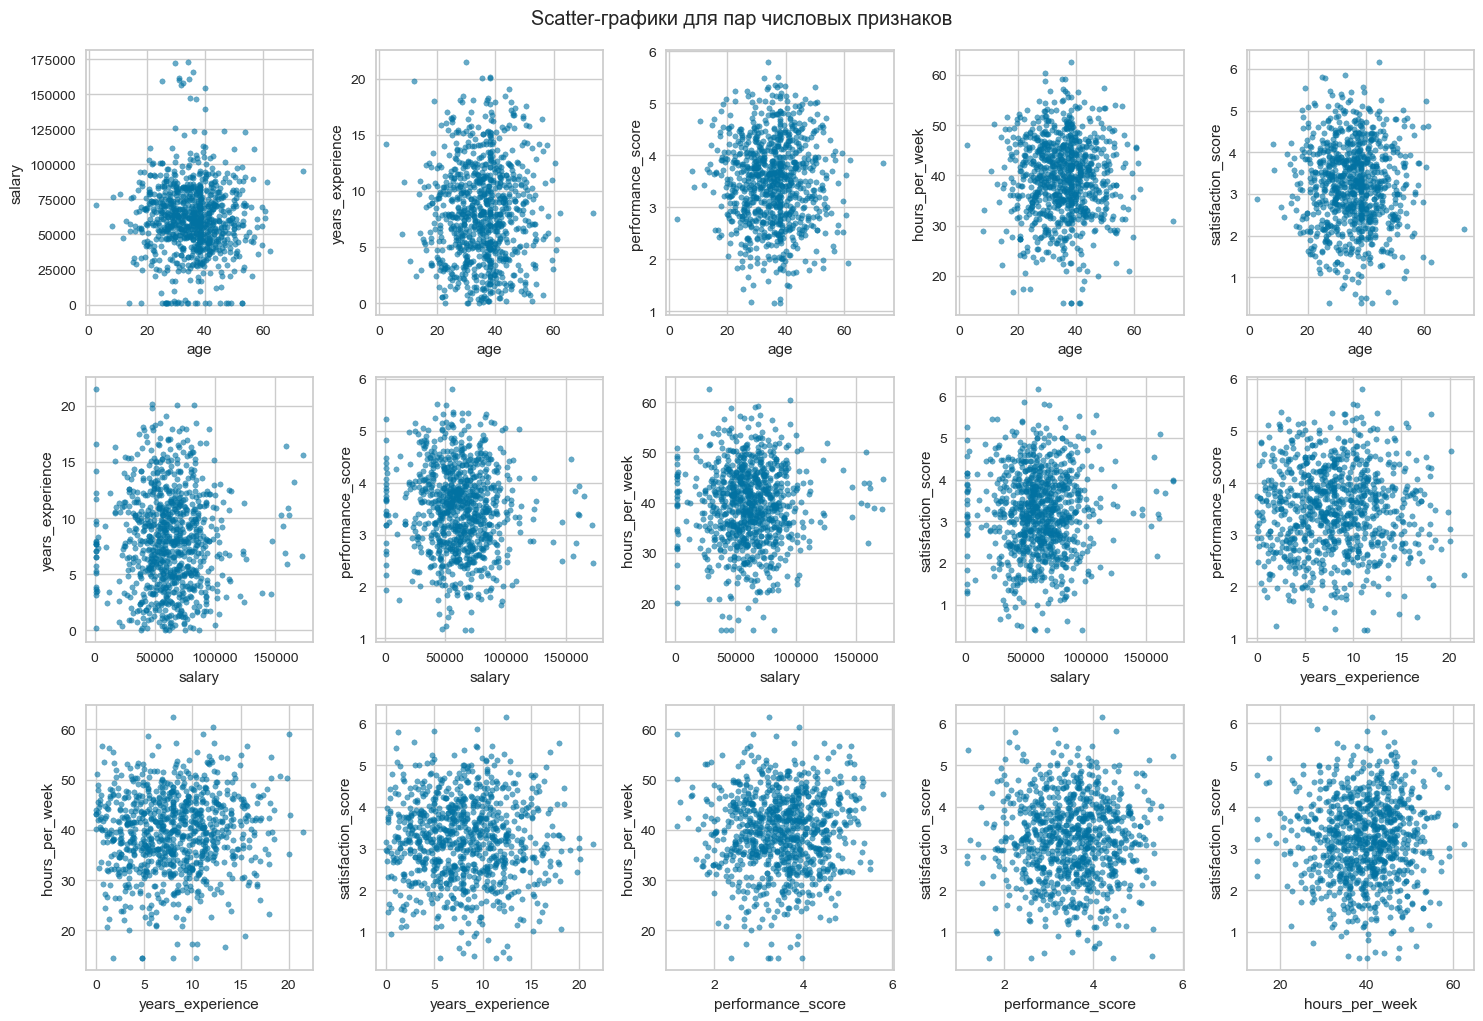

In [12]:
# num_cols — список числовых признаков
features = num_cols[0:8] 
plt.figure(figsize=(15, 10))
plot_num = 1
num_features = len(features)
for i, j in itertools.combinations(range(num_features), 2):
    plt.subplot(3, 5, plot_num)
    plt.scatter(df_cleaned[features[i]], df_cleaned[features[j]], alpha=0.6, s=15)
    plt.xlabel(features[i])
    plt.ylabel(features[j])
    plt.tight_layout()
    plot_num += 1
plt.suptitle('Scatter-графики для пар числовых признаков', y=1.02)
plt.show()

#### Матрица корреляция позволяет найти корреляции между признаками, если она имеет большие значения по модулю (близкие к 1), то такие признаки необходимо обработать с помощью методов инженерии данных: поиска основных признаков и генерации признаков.<br>!ПРИМЕЧАНИЕ: не относится к несвязанным логически признакам!

In [13]:
corr_matrix = df_cleaned.select_dtypes(include=['number']).corr()
print(corr_matrix)

                         age    salary  years_experience  performance_score  \
age                 1.000000 -0.032901          0.016296          -0.010716   
salary             -0.032901  1.000000         -0.003293          -0.074337   
years_experience    0.016296 -0.003293          1.000000           0.011380   
performance_score  -0.010716 -0.074337          0.011380           1.000000   
hours_per_week     -0.008664  0.018011          0.061857           0.028747   
satisfaction_score -0.027303  0.023098         -0.023628          -0.011112   

                    hours_per_week  satisfaction_score  
age                      -0.008664           -0.027303  
salary                    0.018011            0.023098  
years_experience          0.061857           -0.023628  
performance_score         0.028747           -0.011112  
hours_per_week            1.000000           -0.001921  
satisfaction_score       -0.001921            1.000000  


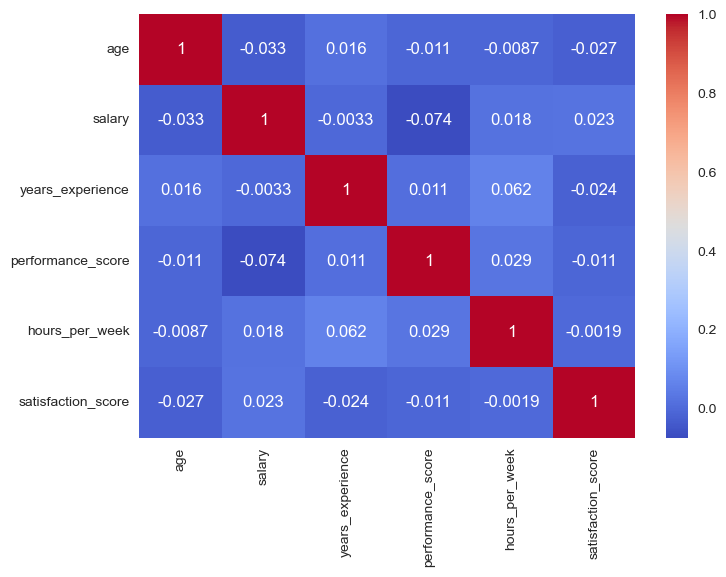

In [14]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

#### Методы понижения  размерности позволяют перейти из пространства большей размерности (если в наборе данных 10 столбиков, то это значит, что в нём 10 признаков, а значит и пространство 10-тимерное) в пространство меньшей размерности (обычно это нужно для визуализации всего массива данных на одном двухмерном или трёхмерном графике, либо для сжатия однотипных признаков в слишком больших наборах, где тяжело определить "лишние" признаки и проще их просто сжать), метод главных компонент (PCA) является наиболее простым методом, но как и все методы, основанные на "компонентах", требует определения объяснённой дисперсии первоначальных данных главными компонентами, если значение значительно меньше 1 (например, 0.8 или даже 0.9, что всё ещё мало), то такое количество главных компонент плохо описывает сущность (взаимосвязи и положение - свойства) первоначальных данных, если речь идёт о двухмерном графике, то это 2 главных компонента

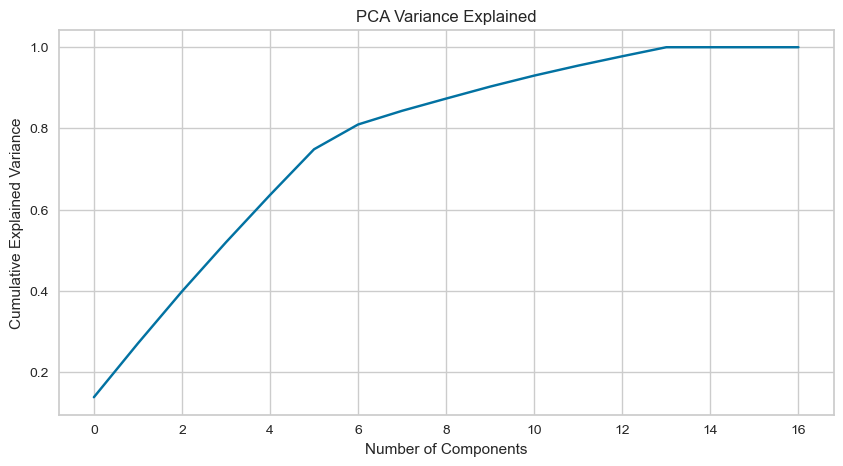

In [15]:
pca = PCA()
pca.fit(X_processed.toarray() if hasattr(X_processed, 'toarray') else X_processed)
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Variance Explained')
plt.show()

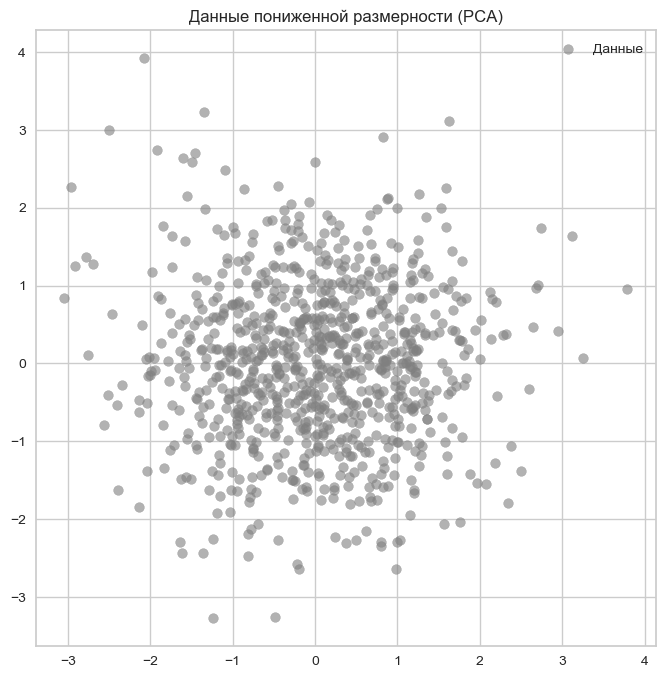

In [16]:
reducer = pca
embedding = reducer.fit_transform(X_processed)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
# 1. До кластеризации (PCA)
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], alpha=0.6, color='gray', label='Данные')
ax.set_title('Данные пониженной размерности (PCA)')
ax.legend()

In [17]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200)
#import plotly.express as px

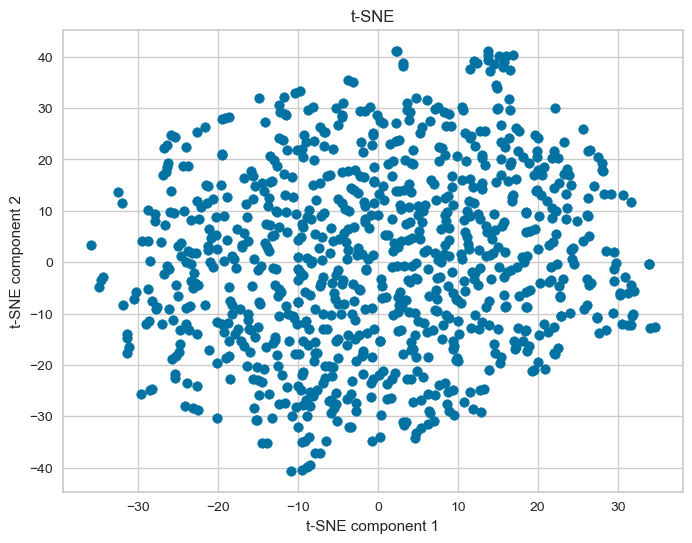

In [18]:
X_tsne = tsne.fit_transform(X_processed)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], cmap='viridis')
plt.legend(handles=scatter.legend_elements()[0])
plt.title('t-SNE')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.show()

#### Метод локтя является одной из основных метрик кластеризации, которая позволяет на основе зависимости внутрикластерной дисперсии от количества кластеров определить необходимо число кластеров для методов, которым число кластеров (необходимо, минимальное или максимальное) нужно в качестве входного параметра

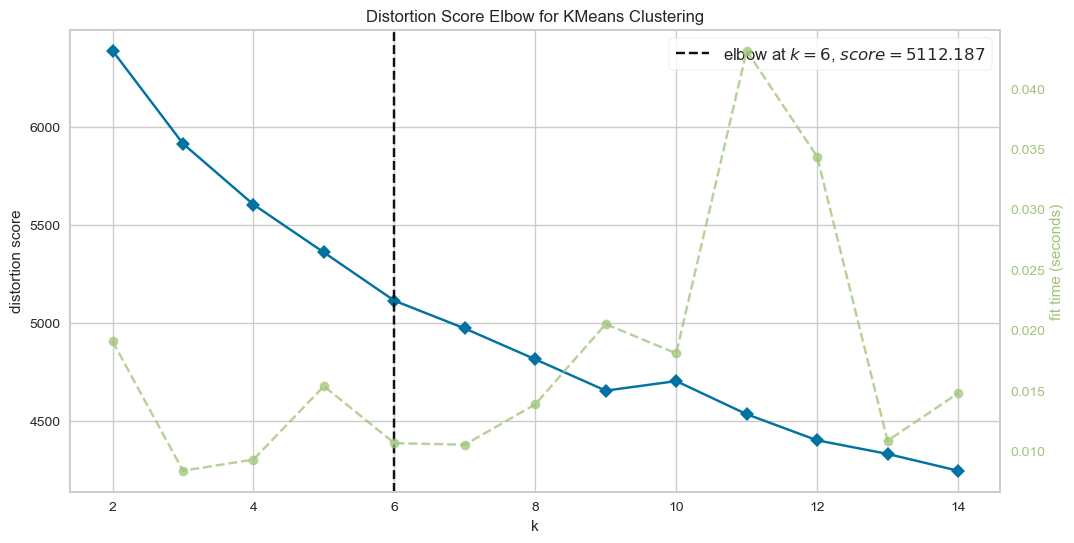

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
#метод локтя 
plt.figure(figsize=(12, 6))
elbow = KElbowVisualizer(KMeans(random_state = 42), k=(2, 15)) # по умолчанию вывод синим цветом метод локтя,
# а пунктирной чёрной линией - сам локоть (точку перегиба, которую и желательно выбирать)
# зелёная пунктирна линия демонстрирует время кластеризации на для такого "k" точек.
elbow.fit(X_processed) # обучение модели на преобработанных данных
elbow.show()

#### Метод силуэта является более универсальным, так как основан на двух других наиболее значимых метриках кластеризации - внутрикластерном (которое нужно минимизировать) и межкластерном расстояниях (которое нужно максимизировать), он определяет, насколько каждая точка в кластере близко находится к другим точкам внутри этого кластера, а также то, насколько близко она находится к точкам других кластеров, если коэффициент положителен и ближе к 1, то точка, вероятнее всего, находится в своём кластере, если отрицателен и ближе к -1, то точка, очень вероятно, находится не в своём кластере, если же ближе к 0, тяжело определить качество кластеризации точки, т.к. она гранична ко всем, возможно, она вообще шумовая, если таких точек много, то разеделение на кластеры выполнено неверно, либо данные слишком разреженные, либо данные некачественные

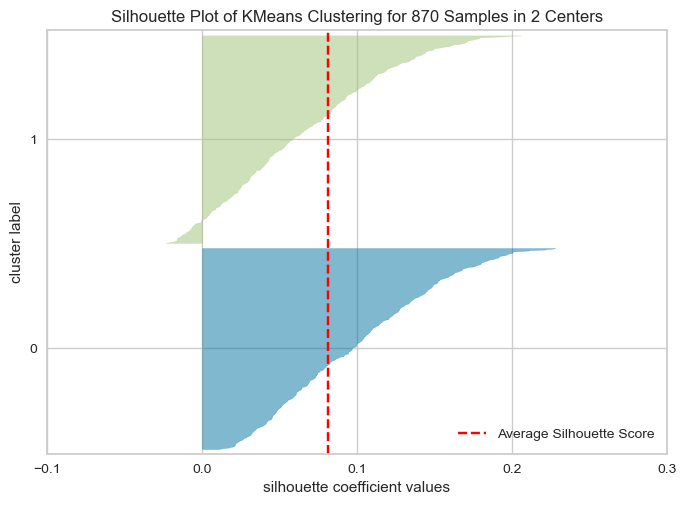

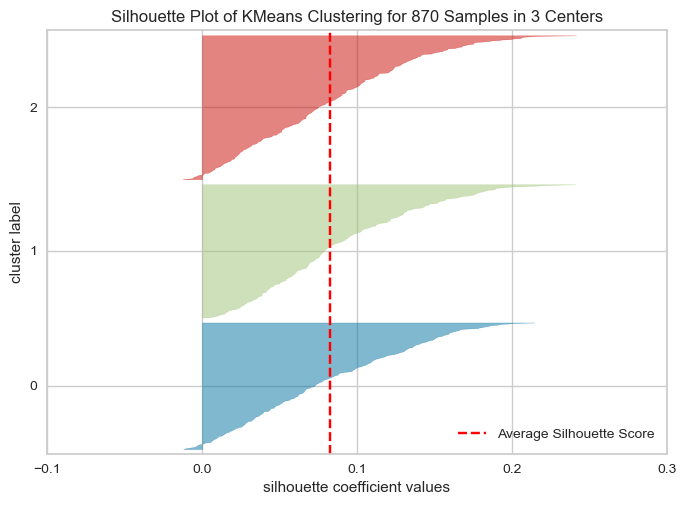

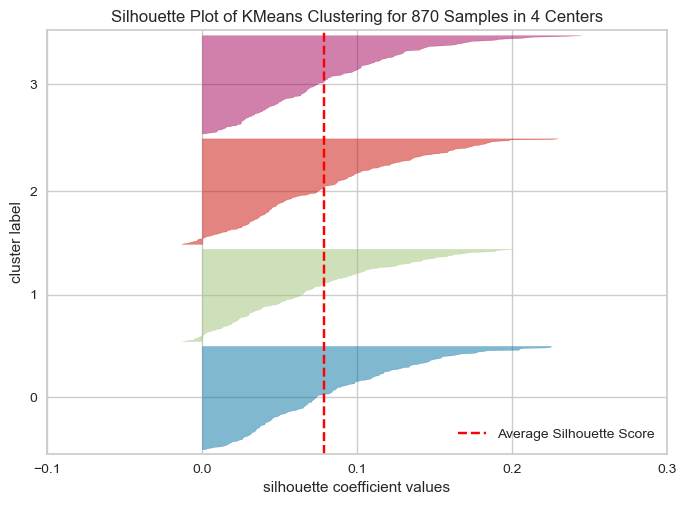

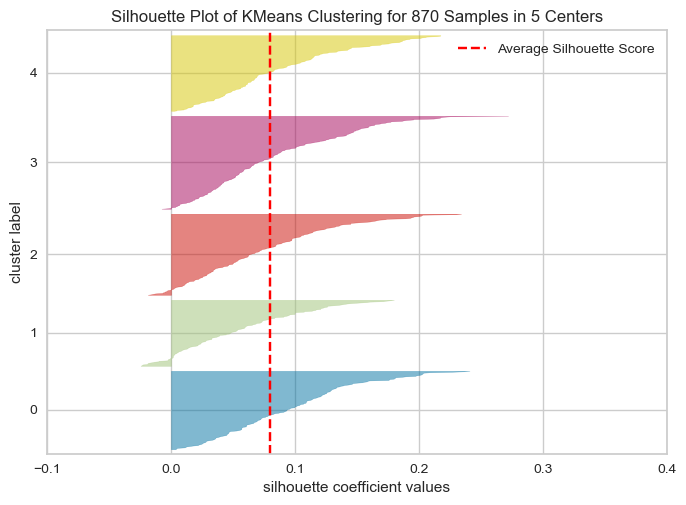

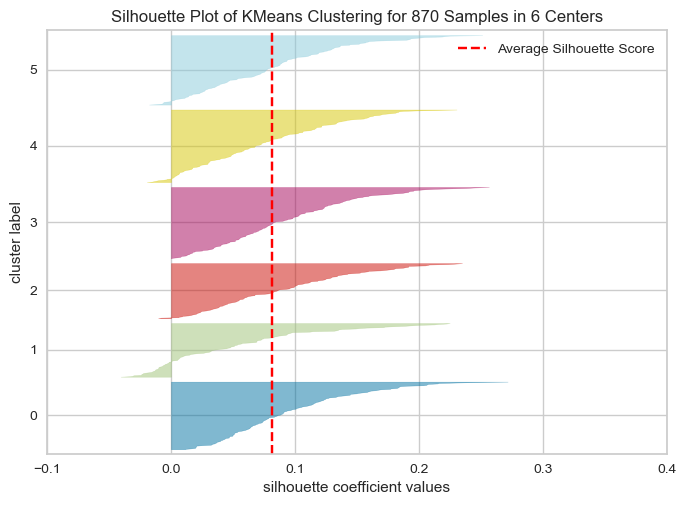

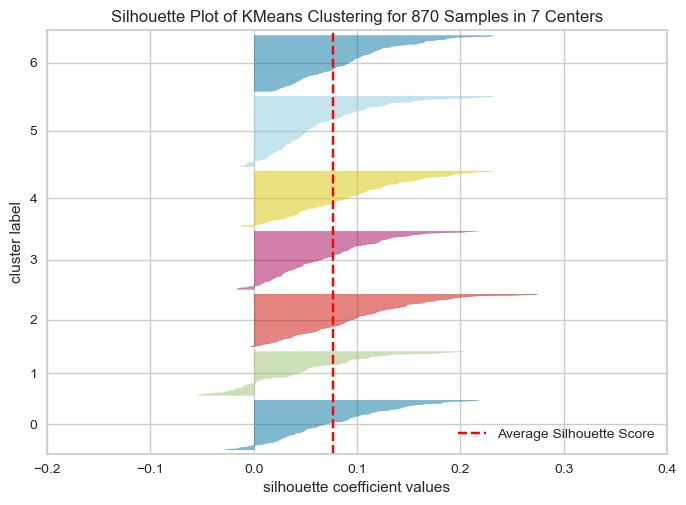

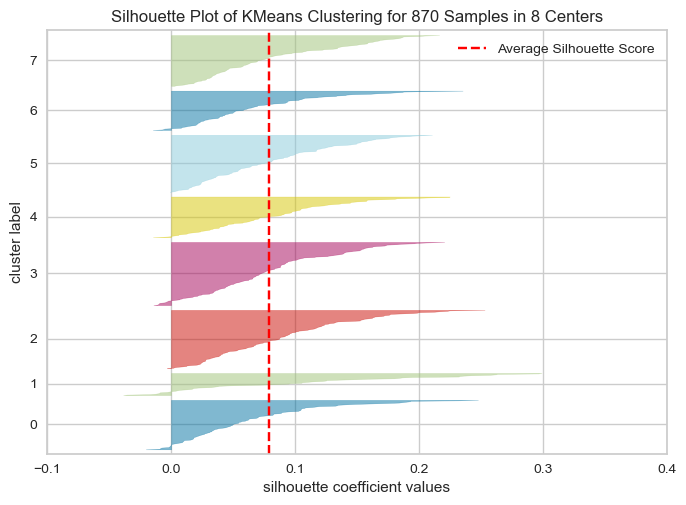

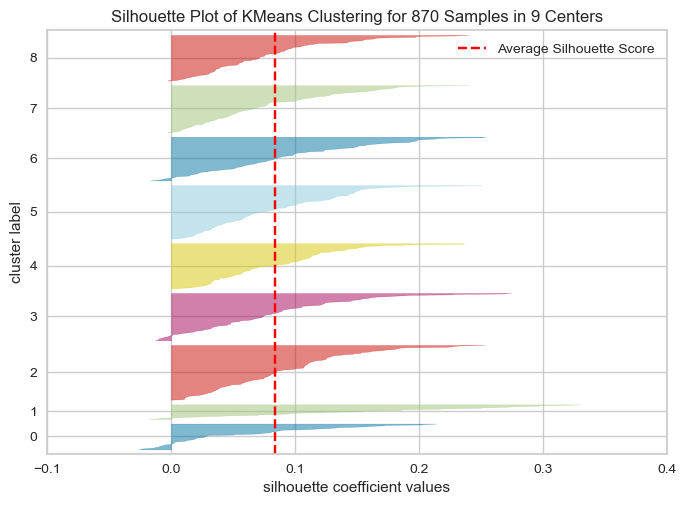

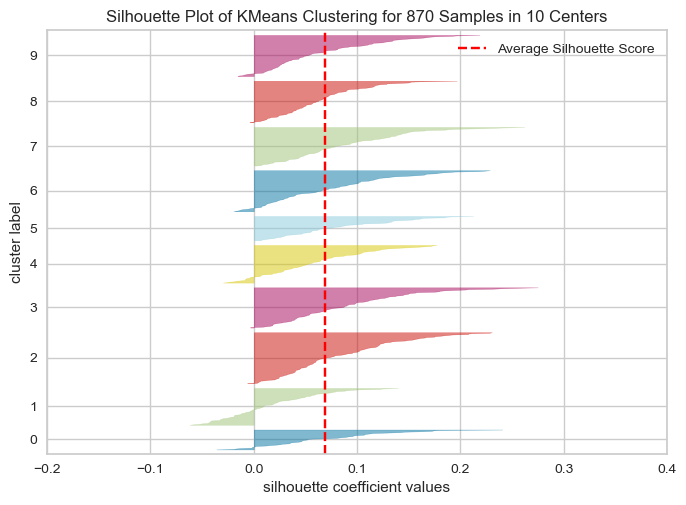

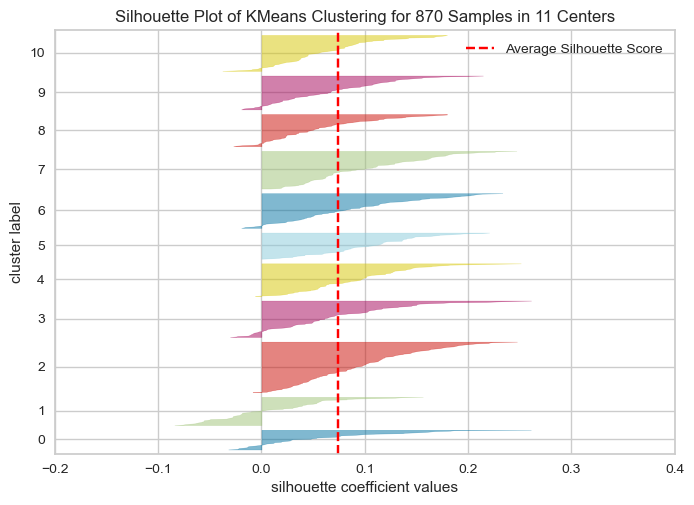

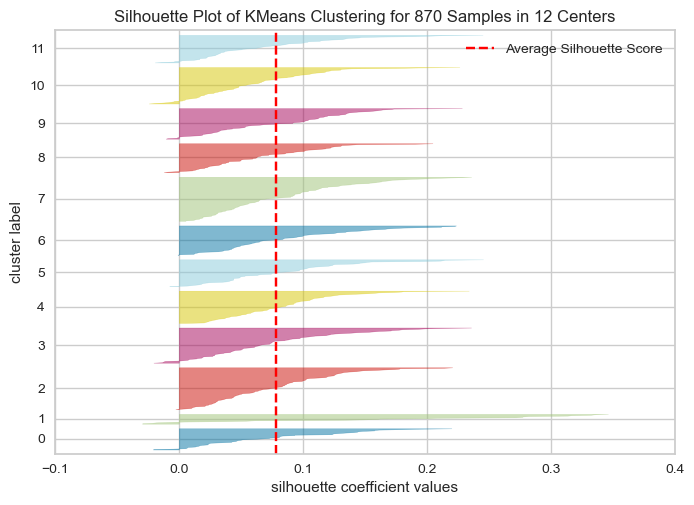

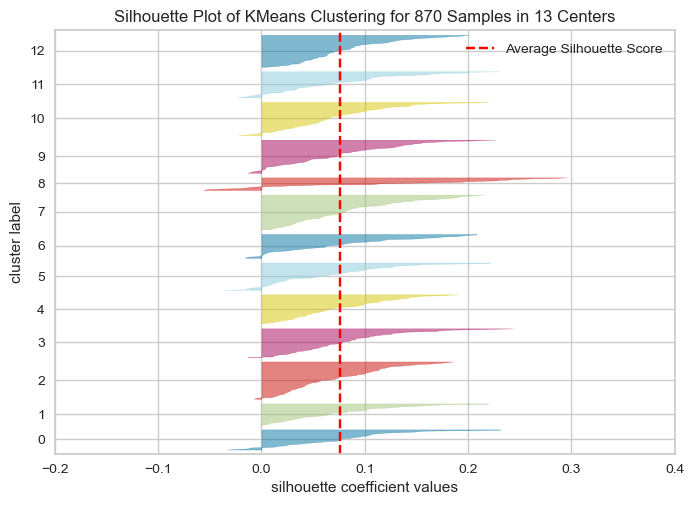

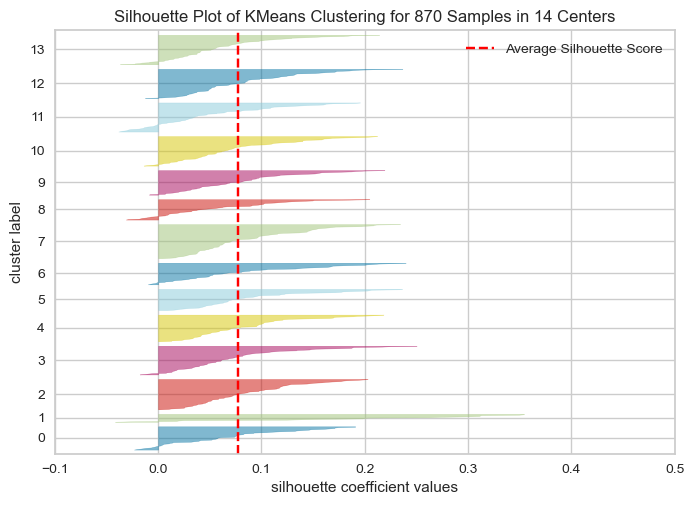

In [20]:
silhouette_scores = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_processed)
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick') # по умолчанию...
    #... график силуэта отображает коэффициент силуэта для каждого образца по кластерам
    # оценка рассчитывается путём усреднения коэффициента силуэта для каждого образца,...
    #...вычисляемого как разница между средним внутрикластерным расстоянием...
    #... и средним расстоянием до ближайшего кластера для каждого образца
    #... нормализованная по максимальному значению
    visualizer.fit(X_processed)
    visualizer.show()
    #silhouette_visualizer(kmeans, X_processed, colors='yellowbrick')

#### Методы понижения  размерности позволяют перейти из пространства большей размерности (если в наборе данных 10 столбиков, то это значит, что в нём 10 признаков, а значит и пространство 10-тимерное) в пространство меньшей размерности (обычно это нужно для визуализации всего массива данных на одном двухмерном или трёхмерном графике, либо для сжатия однотипных признаков в слишком больших наборах, где тяжело определить "лишние" признаки и проще их просто сжать), метод главных компонент (PCA) является наиболее простым методом, но как и все методы, основанные на "компонентах", требует определения объяснённой дисперсии первоначальных данных главными компонентами, если значение значительно меньше 1 (например, 0.8 или даже 0.9, что всё ещё мало), то такое количество главных компонент плохо описывает сущность (взаимосвязи и положение - свойства) первоначальных данных, если речь идёт о двухмерном графике, то это 2 главных компонента

#### Одним из основных и простейших методов кластерзации является метод k-means, который относится к центроидным методам (кластер формируется на основе центра, расстояние до которого у точки должен быть меньше, чем к остальльным), сущность метода заключается в определении центроидов (центро кластеров) как геометрического центра между всеми точками в кластере и определении ближайшего центроида к каждой из точек, подобные методы лучше всего работают в условиях скопления находящихся друг от друга на достаточном расстоянии окружностях, однако в реальных данных это нечастое явление

In [21]:
kmeans = KMeans(n_clusters=7, random_state=42)
kmeans_labels = kmeans.fit_predict(X_processed)

#### В условиях плотных данных и концентрических объектов (например, окружностях) лучше всего применять плотностные методы, основным и простейшим из которых является DBSCAN, задачей которого является не только объединение точек в кластеры, но и удаление из набора шумовых точек, общей принцип работы основан на двух показателях - Эпсилон-окрестности и минимальном количестве точек в этой окрестности: если точек в окрестности больше или равно минимальному значению, то точка является ядром кластера, если нет, но она входит в чужие ядерные окрестности, то она граничная, если ничего из этого не выполняется, то такая точка является шумом
#### Наиболее сложным в процессе обучения DBSCAN и его модификаций и вариаций является подбор оптимальных значний гиперпараметров (Эпсилон-окрестности и минимального количестве точек в ней), для этого можно перебором вычислять наилучшее значение коэффициента силуэта

In [22]:
# Подберите eps в районе излома k-distance plot
def safe_silhouette_score(X, labels):
    unique_clusters = set(labels)
    unique_clusters.discard(-1)
    # Нужны не менее 2 кластеров
    if len(unique_clusters) < 2:
        return None
    # В каждом кластере минимум 2 точки
    for label in unique_clusters:
        if sum(labels == label) < 2:
            return None
    return silhouette_score(X, labels)
eps_values = [(i/10)+0.1 for i in range(100)] # список точек от 0 до 10 с шагом в 0.1
best_silhouette_score = [0, 0, 0]
for samples in range (1, 20):
    for eps_value in eps_values:
        dbscan = DBSCAN(eps=eps_value, min_samples=samples)
        labels = dbscan.fit_predict(X_processed)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        #if n_clusters > 1:
        score = safe_silhouette_score(X_processed, labels)
        if score is not None:
            if silhouette_score(X_processed, labels) > best_silhouette_score[2]:
                best_silhouette_score[0] = samples
                best_silhouette_score[1] = eps_value
                best_silhouette_score[2] = score
                print(f'Новый лучший силуэт: eps={best_silhouette_score[1]}: кластеры={best_silhouette_score[0]}, шум={n_noise}, силуэт={best_silhouette_score[2]:.3f}')
        #else:
            #print(f'eps={eps_value}, n_clusters={n_clusters}: все точки — один кластер или только шум')
print(f'Лучший силуэт: eps={best_silhouette_score[1]}: кластеры={best_silhouette_score[0]}, силуэт={best_silhouette_score[2]:.3f}')        

Новый лучший силуэт: eps=2.3000000000000003: кластеры=2, шум=45, силуэт=0.068
Новый лучший силуэт: eps=2.4: кластеры=2, шум=26, силуэт=0.079
Новый лучший силуэт: eps=2.3000000000000003: кластеры=3, шум=49, силуэт=0.099
Лучший силуэт: eps=2.3000000000000003: кластеры=3, силуэт=0.099


#### Для DBSCAN есть свой "метод локтя", называемый "k-distance", на котором можно увидеть характер изменения количества точек в кластере в зависимости от значения Эпсилон, выбирать рекомендуется точку наиболее резкого увеличения по оси y (либо ближайшие соседние)

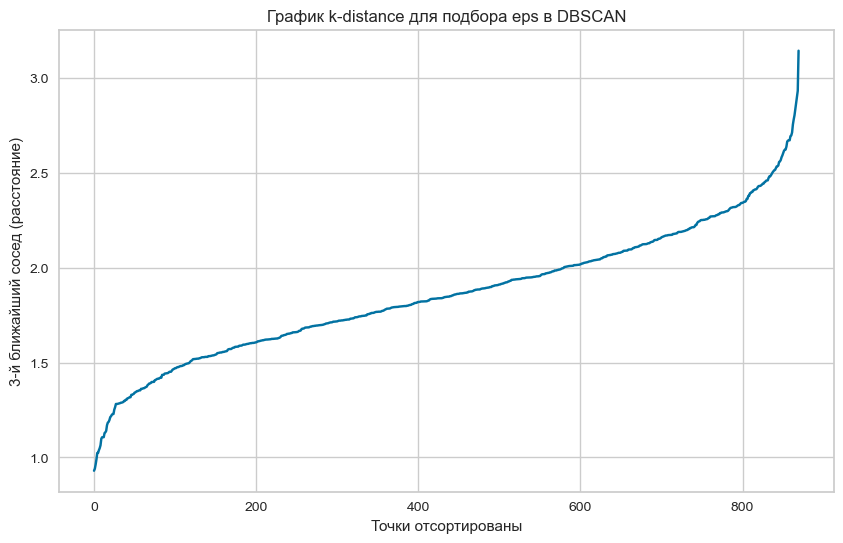

In [23]:
k = 3
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_processed)
distances, _ = nbrs.kneighbors(X_processed)
# Берём расстояния до k-го (последнего) соседа для каждой точки
k_distances = distances[:, k-1]
k_distances = np.sort(k_distances)
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.ylabel(f'{k}-й ближайший сосед (расстояние)')
plt.xlabel('Точки отсортированы')
plt.title('График k-distance для подбора eps в DBSCAN')
plt.grid(True)
plt.show()

In [24]:
dbscan = DBSCAN(eps=best_silhouette_score[1], min_samples=best_silhouette_score[0])
dbscan_labels = dbscan.fit_predict(X_processed)

In [25]:
agg = AgglomerativeClustering(n_clusters=elbow.elbow_value_)
agg_labels = agg.fit_predict(X_processed.toarray() if hasattr(X_processed, 'toarray') else X_processed)

#### С помощью понижения размерности можно вывести базовое распределние признаков и результаты кластеризации на график, это нужно для того, чтобы было возможно визуально оценить качество кластеризации (например, если данные явно представлены совокупностью ярко выраженных геометрических примитивов), если же базовое распределение признаков имеет случайный характер (не имеет явных закономерностей) или данные распределены равномерно (либо любым другим законом распределения, близкому к равномерному), то найти какие-либо связи в данных будет тяжело, тем более визуально

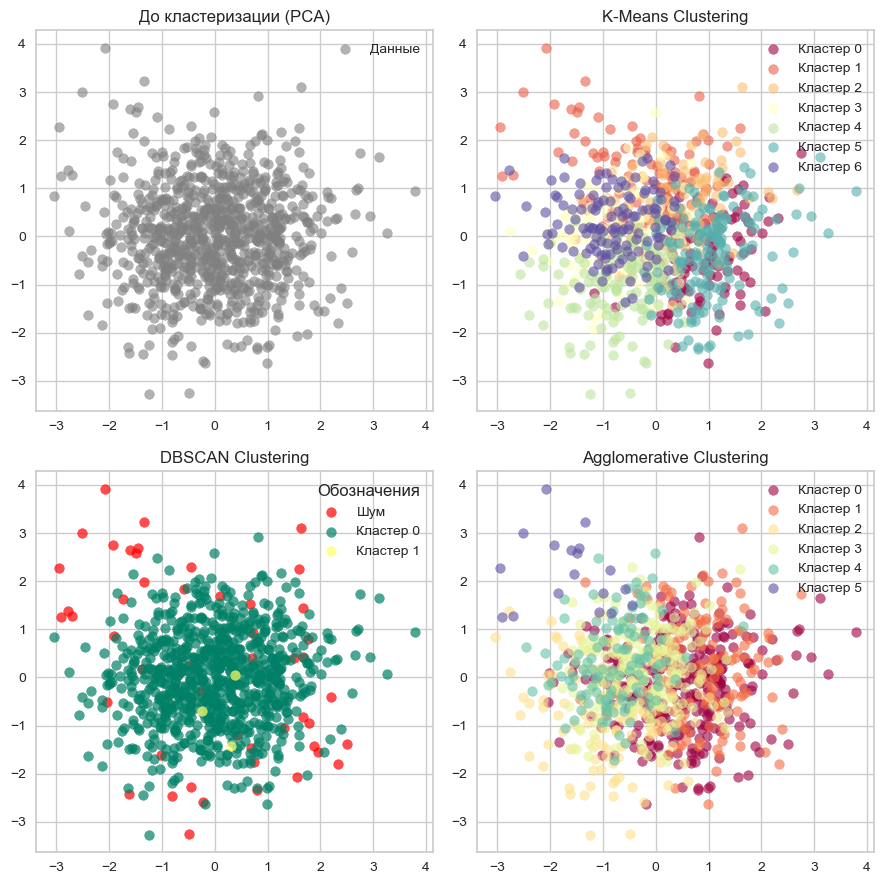

In [26]:
reducer = pca
embedding = reducer.fit_transform(X_processed)
fig, ax = plt.subplots(2, 2, figsize=(9, 9))
# 1. До кластеризации (PCA)
scatter = ax[0, 0].scatter(embedding[:, 0], embedding[:, 1], alpha=0.6, color='gray', label='Данные')
ax[0, 0].set_title('До кластеризации (PCA)')
ax[0, 0].legend()
# 2. K-Means:
unique_k = np.unique(kmeans_labels)
cmap_k = cm.get_cmap('Spectral', len(unique_k))
for label in unique_k:
    idx = kmeans_labels == label
    ax[0, 1].scatter(
        embedding[idx, 0], embedding[idx, 1],
        c=[cmap_k(label)], alpha=0.6, label=f'Кластер {label}'
    )
ax[0, 1].set_title('K-Means Clustering')
ax[0, 1].legend()
# 3. DBSCAN:
unique_db = np.unique(dbscan_labels)
n_clusters_db = len(unique_db) - (1 if -1 in unique_db else 0)
cmap_db = cm.get_cmap('summer', n_clusters_db if n_clusters_db > 0 else 1)
legend_handles_db = []
cluster_cnt = 0
for label in unique_db:
    idx = dbscan_labels == label
    if label == -1:
        sc = ax[1, 0].scatter(
            embedding[idx, 0], embedding[idx, 1],
            c='red', alpha=0.7, label='Шум'
        )
        legend_handles_db.append(sc)
    else:
        color = cmap_db(cluster_cnt)
        sc = ax[1, 0].scatter(
            embedding[idx, 0], embedding[idx, 1],
            c=[color], alpha=0.7, label=f'Кластер {label}'
        )
        legend_handles_db.append(sc)
        cluster_cnt += 1
ax[1, 0].set_title('DBSCAN Clustering')
ax[1, 0].legend(handles=legend_handles_db, title='Обозначения')
# 4. Agglomerative:
unique_a = np.unique(agg_labels)
cmap_a = cm.get_cmap('Spectral', len(unique_a))
for label in unique_a:
    idx = agg_labels == label
    ax[1, 1].scatter(
        embedding[idx, 0], embedding[idx, 1],
        c=[cmap_a(label)], alpha=0.6, label=f'Кластер {label}'
    )
ax[1, 1].set_title('Agglomerative Clustering')
ax[1, 1].legend()
plt.tight_layout()
plt.show()

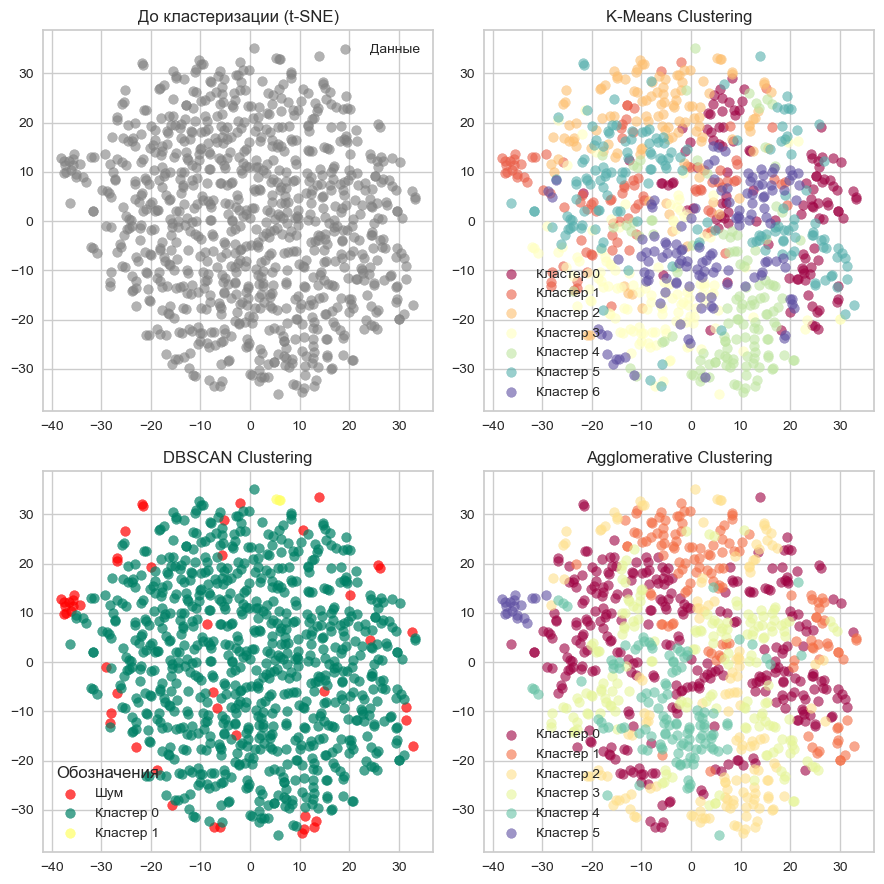

In [27]:
embedding = tsne.fit_transform(X_processed)
fig, ax = plt.subplots(2, 2, figsize=(9, 9))
# 1. До кластеризации (PCA)
scatter = ax[0, 0].scatter(embedding[:, 0], embedding[:, 1], alpha=0.6, color='gray', label='Данные')
ax[0, 0].set_title('До кластеризации (t-SNE)')
ax[0, 0].legend()
# 2. K-Means:
unique_k = np.unique(kmeans_labels)
cmap_k = cm.get_cmap('Spectral', len(unique_k))
for label in unique_k:
    idx = kmeans_labels == label
    ax[0, 1].scatter(
        embedding[idx, 0], embedding[idx, 1],
        c=[cmap_k(label)], alpha=0.6, label=f'Кластер {label}'
    )
ax[0, 1].set_title('K-Means Clustering')
ax[0, 1].legend()
# 3. DBSCAN:
unique_db = np.unique(dbscan_labels)
n_clusters_db = len(unique_db) - (1 if -1 in unique_db else 0)
cmap_db = cm.get_cmap('summer', n_clusters_db if n_clusters_db > 0 else 1)
legend_handles_db = []
cluster_cnt = 0
for label in unique_db:
    idx = dbscan_labels == label
    if label == -1:
        sc = ax[1, 0].scatter(
            embedding[idx, 0], embedding[idx, 1],
            c='red', alpha=0.7, label='Шум'
        )
        legend_handles_db.append(sc)
    else:
        color = cmap_db(cluster_cnt)
        sc = ax[1, 0].scatter(
            embedding[idx, 0], embedding[idx, 1],
            c=[color], alpha=0.7, label=f'Кластер {label}'
        )
        legend_handles_db.append(sc)
        cluster_cnt += 1
ax[1, 0].set_title('DBSCAN Clustering')
ax[1, 0].legend(handles=legend_handles_db, title='Обозначения')
# 4. Agglomerative:
unique_a = np.unique(agg_labels)
cmap_a = cm.get_cmap('Spectral', len(unique_a))
for label in unique_a:
    idx = agg_labels == label
    ax[1, 1].scatter(
        embedding[idx, 0], embedding[idx, 1],
        c=[cmap_a(label)], alpha=0.6, label=f'Кластер {label}'
    )
ax[1, 1].set_title('Agglomerative Clustering')
ax[1, 1].legend()
plt.tight_layout()
plt.show()

#### Оценка важности признаков кластеризации можно выполнить разными способами (Leave-One-Out, Ensemble Feature Ranking, Supervised Clustering with SHAP, Feature Clustering Methods), но проще (и лучше) всего реализовать её через классификацию (коэффициенты модели, Gini Importance, Permutation Feature Importance), так как точки уже распределены по кластерам, то кластеры можно принять за классы и обучить на этом модель, у метода случайного леса есть своя метрика - индекс снижения примеси:
__Gini = 1 - Σ(pi²):__ 

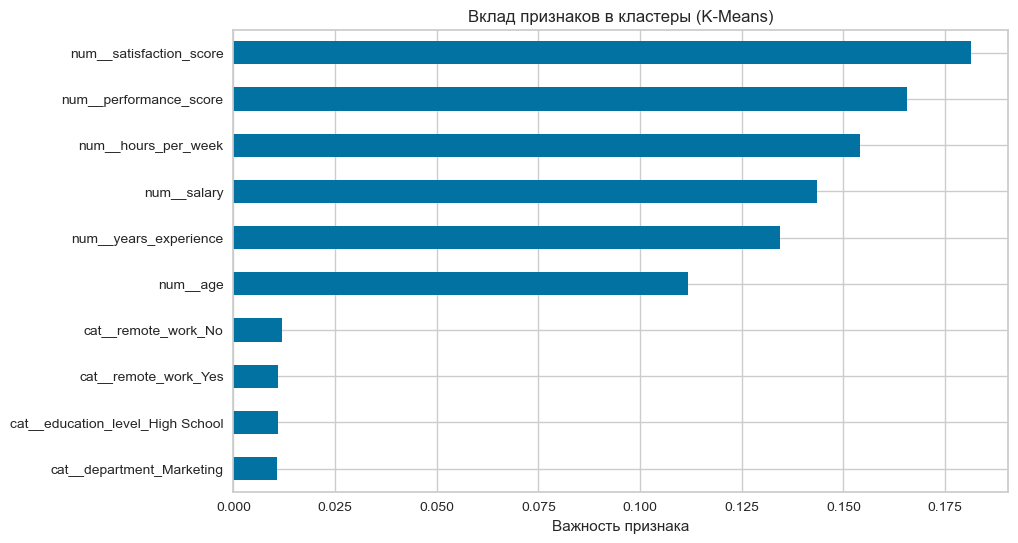

In [28]:
# Оценка важности признаков с помощью RandomForestClassifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_processed, kmeans_labels)
feature_names = preprocessor.get_feature_names_out()
importances = clf.feature_importances_
# Визуализация топ-10 признаков
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
importance_series.head(10).plot(kind='barh', figsize=(10, 6))
plt.title('Вклад признаков в кластеры (K-Means)')
plt.xlabel('Важность признака')
plt.gca().invert_yaxis()
plt.show()

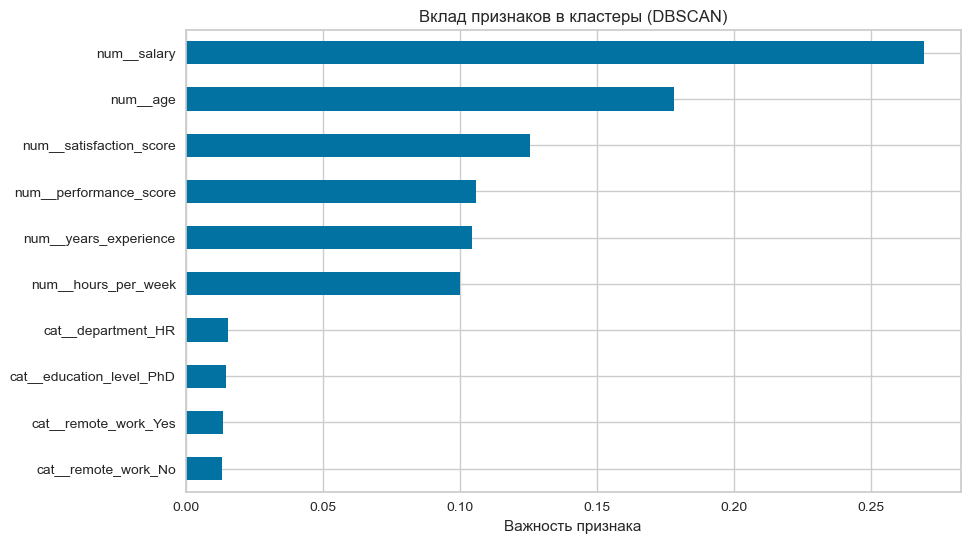

In [29]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_processed, dbscan_labels)
feature_names = preprocessor.get_feature_names_out()
importances = clf.feature_importances_
# Визуализация топ-10 признаков
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
importance_series.head(10).plot(kind='barh', figsize=(10, 6))
plt.title('Вклад признаков в кластеры (DBSCAN)')
plt.xlabel('Важность признака')
plt.gca().invert_yaxis()
plt.show()

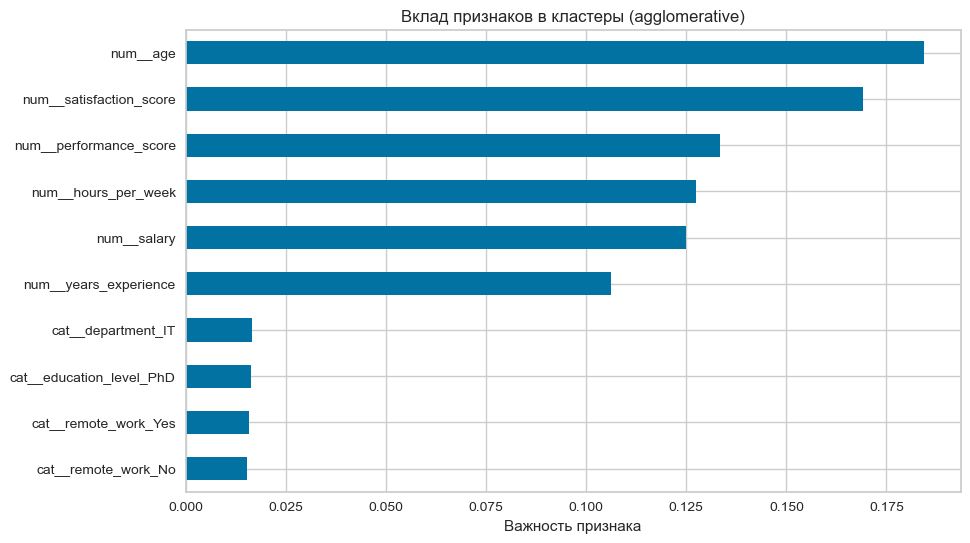

In [30]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_processed, agg_labels)
feature_names = preprocessor.get_feature_names_out()
importances = clf.feature_importances_
# Визуализация топ-10 признаков
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
importance_series.head(10).plot(kind='barh', figsize=(10, 6))
plt.title('Вклад признаков в кластеры (agglomerative)')
plt.xlabel('Важность признака')
plt.gca().invert_yaxis()
plt.show()

#### Норма по каждому из признаков:
##### Среднее по столбцу age: 38.65748173709172 Мода по стобцу: 100.0
##### Среднее по столбцу salary: 67789.95386780548 Мода по стобцу: 62453.40631989591
##### Среднее по столбцу years_experience: 8.181248212627406 Мода по стобцу: 7.882239245628809
##### Среднее по столбцу performance_score: 3.4997703613937174 Мода по стобцу: 3.5240251833312657
##### Среднее по столбцу hours_per_week: 39.53390225628822 Мода по стобцу: 39.821597730255576
##### Среднее по столбцу satisfaction_score: 3.2157900617116892 Мода по стобцу: 3.2235762444305114

#### Наконец, с помощью того же случайного леса можно определить важность признаков для каждого из кластеров, а потом вывести топ этих признаков, чтобы было понятно, какой признак наиболее ярко выражен, также стоит вывести модальное, медианное или среднее значение для этого признака (в зависимости от типа самого признака)

In [31]:
main_features_top3 = {}
for cluster_label in np.unique(kmeans_labels):
    binary_target = (kmeans_labels == cluster_label).astype(int)
    clf_local = RandomForestClassifier(random_state=42)
    clf_local.fit(X_processed, binary_target)
    importances = clf_local.feature_importances_
    top_indices = importances.argsort()[::-1][:3]
    top_names = feature_names[top_indices]
    main_features_top3[cluster_label] = top_names
results = []
for cluster_label, top_names in main_features_top3.items():
    row = {'Кластер': cluster_label}
    for i, top_feature_name in enumerate(top_names, start=1):
        if '_' in top_feature_name and top_feature_name.startswith('cat__'):
            # Пример: 'cat__department_IT'
            origin, col_val = top_feature_name.split('__', 1)
            col, val = col_val.split('_', 1)
            row[f'Признак {i}'] = col
            row[f'Значение {i}'] = val
        elif top_feature_name.startswith('num__'):
            # Пример: 'num__salary'
            col = top_feature_name.split('__')[1]
            median_val = df_cleaned.loc[kmeans_labels == cluster_label, col].median()
            row[f'Признак {i}'] = col
            row[f'Значение {i}'] = median_val
        else:
            # fallback для нестандартных признаков
            col = top_feature_name
            cluster_data = df_cleaned.loc[kmeans_labels == cluster_label, col]
            if pd.api.types.is_numeric_dtype(cluster_data):
                val = cluster_data.median()
            else:
                val = cluster_data.mode().iloc[0] if not cluster_data.mode().empty else np.nan
            row[f'Признак {i}'] = col
            row[f'Значение {i}'] = val
    results.append(row)
results_df = pd.DataFrame(results)
print(results_df)

   Кластер           Признак 1    Значение 1           Признак 2  Значение 2  \
0        0              salary  38433.760711   performance_score    4.281681   
1        1              salary  87601.827083    years_experience   10.860287   
2        2    years_experience     12.608251                 age   42.175423   
3        3   performance_score      2.552776  satisfaction_score    2.598498   
4        4      hours_per_week     28.538630   performance_score    3.686229   
5        5  satisfaction_score      2.187713   performance_score    3.921314   
6        6    years_experience      4.175143  satisfaction_score    4.015975   

            Признак 3  Значение 3  
0  satisfaction_score    3.708186  
1                 age   29.965243  
2  satisfaction_score    3.859828  
3    years_experience    5.959496  
4  satisfaction_score    3.434730  
5                 age   40.836059  
6      hours_per_week   43.569953  


In [32]:
main_features_top3 = {}
# Исключаем шум (-1), анализируем только "настоящие" кластеры
unique_dbscan_clusters = [label for label in np.unique(dbscan_labels) if label != -1]
for cluster_label in unique_dbscan_clusters:
    binary_target = (dbscan_labels == cluster_label).astype(int)
    clf_local = RandomForestClassifier(random_state=42)
    clf_local.fit(X_processed, binary_target)
    importances = clf_local.feature_importances_
    top_indices = importances.argsort()[::-1][:3]
    top_names = feature_names[top_indices]
    main_features_top3[cluster_label] = top_names
results = []
for cluster_label, top_names in main_features_top3.items():
    row = {'Кластер': cluster_label}
    for i, top_feature_name in enumerate(top_names, start=1):
        if '_' in top_feature_name and top_feature_name.startswith('cat__'):
            origin, col_val = top_feature_name.split('__', 1)
            col, val = col_val.split('_', 1)
            row[f'Признак {i}'] = col
            row[f'Значение {i}'] = val
        elif top_feature_name.startswith('num__'):
            col = top_feature_name.split('__')[1]
            median_val = df_cleaned.loc[dbscan_labels == cluster_label, col].median()
            row[f'Признак {i}'] = col
            row[f'Значение {i}'] = median_val
        else:
            # резерв на случай нестандартных имён
            col = top_feature_name
            cluster_data = df_cleaned.loc[dbscan_labels == cluster_label, col]
            if pd.api.types.is_numeric_dtype(cluster_data):
                val = cluster_data.median()
            else:
                val = cluster_data.mode().iloc[0] if not cluster_data.mode().empty else np.nan
            row[f'Признак {i}'] = col
            row[f'Значение {i}'] = val
    results.append(row)
results_df = pd.DataFrame(results)
print(results_df)

   Кластер Признак 1    Значение 1           Признак 2  Значение 2  \
0        0    salary  61008.059561                 age   35.868184   
1        1       age     54.094166  satisfaction_score    4.619771   

            Признак 3  Значение 3  
0  satisfaction_score    3.226783  
1    years_experience   12.840923  


## Раздел генеративного ИИ

In [33]:
from sklearn.mixture import GaussianMixture #модель кластеризации с генеративными свойствами, исторически одна из первых генеративных моделей
from scipy.stats import gaussian_kde # scipy - надстройка Numpy для математических моделей, в данном случае загружается нормальная модель
from sdv.single_table import CTGANSynthesizer #архитектура CTGAN, основанная на GAN, но в отличие от TGAN основана не на рекуррентных, а на полносвязных слоях
from sdv.metadata import SingleTableMetadata # библиотека для описания структуры (метаданных) одной таблицы данных в 2D-формате, автоматически определяет типы данных, первичные ключи и описывает столбцы (имя, тип данных, например, Boolean, Categorical, DateTime) для корректной генерации табличных синтетических данных
from scipy.stats import linregress # линейная регрессионная модель для создания линейных зависимостей между переменными

#### Преобработка данных, аналогичная 1-2 практикам

In [37]:
df_real = pd.read_csv('employees_data.csv')
#df_original = pd.read_csv(FILE_PATH)
df_clean = df_real.copy()
#for col in num_cols:
#    df_clean[col].fillna(df_clean[col].median(), inplace=True)
#for col in cat_cols:
#    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
if 'employee_id' in df_clean.columns:
    df_clean.drop('employee_id', axis=1, inplace=True)
df_clean = df_clean.dropna(how='all') #удаление строк, где пропущены все значения
df_clean = df_clean.dropna(thresh=len(df.columns) - 2) #полное удаление строк, где более 2 пропусков
df_clean = df_clean.dropna(subset=['performance_score', 'hours_per_week', 'satisfaction_score', 'salary']) #удаление строк с пропуском
df_clean.loc[df_clean['years_experience'] < 0, 'years_experience'] = df_clean.loc[df_clean['years_experience'] < 0, 'years_experience'].abs()
cat_cols = df_clean.select_dtypes(include=['object']).columns #выбор колонок с категориальными данными
num_cols = df_clean.select_dtypes(include=['float64']).columns #выбор колонок с числовыми данными
num_imputer = SimpleImputer(strategy='median') #восстановление пропущенных значений медианой
df_clean[num_cols] = num_imputer.fit_transform(df_clean[num_cols])
for col in num_cols:
    mode_val = df_clean[col].mode()[0] #расчёт моды пропущенных значений модой
    std = df_clean[col].std() #'''вычисление стандартной оценки,
    mean = df_clean[col].mean() #вычисление среднего арифметического
    values = df_clean.loc[abs(df_clean[col] - mean) > 3*std, col]
    if mode_val < df_clean[col].max():
        df_clean[col] = np.where( #выбор элементов по запросу
            abs(df_clean[col] - mean) > 3 * std, #модуль разницы между значением и средним больше трёх стандартных отклонений
            mode_val,#заменить модой
            df_clean[col] #иначе оставить как есть
        )
    else:
        df_clean[col] = np.where( #выбор элементов по запросу
            abs(df_clean[col] - mean) > 3 * std, #модуль разницы между значением и средним больше трёх стандартных отклонений
            mean,#заменить средним
            df_clean[col] #иначе оставить как есть
        )
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols), #масштабирует числовое данные относительно стандартного отклонения
        ('cat', OneHotEncoder(), cat_cols) #преобразует категориальные данные числовые стобцы с бинарным признаком для каждого класса
    ]
)
X_processed = preprocessor.fit_transform(df_cleaned)
num_cols = ['age', 'salary', 'years_experience', 'performance_score', 'hours_per_week', 'satisfaction_score']
cat_cols = ['department', 'education_level', 'remote_work'] #num_cols = df_cleaned.select_dtypes(include=['float64']).columns #

### ЭКСПЕРТНАЯ ГЕНЕРАЦИЯ (ПРОДУКЦИОННЫЕ ПРАВИЛА) 

#### Требует извлечения экспертных правил о предметной области задачи и зависимостях внутри данных, простейшим способом является извлечение априорных маргинальных признаков отдельных столбцов (то есть генерация значений каждого отдельного столбика без учёта значений другого, а то есть и без логических условий if-elif-else).

In [38]:
stats = {}
for col in num_cols:
    stats[col] = {
        'mean': df_clean[col].mean(),
        'std': df_clean[col].std(),
        'median': df_clean[col].median(),
        'min': df_clean[col].min(),
        'max': df_clean[col].max()
    }
dept_probs = df_clean['department'].value_counts(normalize=True).to_dict()
edu_probs = df_clean['education_level'].value_counts(normalize=True).to_dict()
remote_probs = df_clean['remote_work'].value_counts(normalize=True).to_dict()
slope, intercept, r_value, p_value, std_err = linregress(df_clean['age'], df_clean['salary']) #генерация простых линейных зависимостей
# Зависимость опыта от возраста: опыт не может превышать возраст-18, плюс шум
# Удовлетворённость от зарплаты и возраста - слабая, поэтому используем нормальное распределение
def generate_expert_rules(n_samples=1000):
    data = []
    for index in range(n_samples):
        age = np.random.normal(stats['age']['mean'], stats['age']['std'])
        age = np.clip(age, 18, 100)
        salary = intercept + slope * age + np.random.normal(0, stats['salary']['std']*0.3)
        salary = np.clip(salary, 0, 500000)
        max_exp = max(0, age - 18)
        years_exp = np.random.normal(0.6 * max_exp, max_exp*0.2)
        years_exp = np.clip(years_exp, 0, max_exp)
        perf = np.random.normal(stats['performance_score']['mean'], stats['performance_score']['std'])
        perf = np.clip(perf, 0, 6)
        hours = np.random.normal(stats['hours_per_week']['mean'], stats['hours_per_week']['std'])
        hours = np.clip(hours, 0, 80)
        sat = np.random.normal(stats['satisfaction_score']['mean'], stats['satisfaction_score']['std'])
        sat = np.clip(sat, 0, 10)
        dept = np.random.choice(list(dept_probs.keys()), p=list(dept_probs.values()))
        edu = np.random.choice(list(edu_probs.keys()), p=list(edu_probs.values()))
        remote = np.random.choice(list(remote_probs.keys()), p=list(remote_probs.values()))
        data.append([age, salary, years_exp, perf, hours, sat, dept, edu, remote])
    cols = num_cols + cat_cols
    return pd.DataFrame(data, columns=cols)
df_expert = generate_expert_rules(len(df_clean))

In [39]:
print(df_expert.head())

         age        salary  years_experience  performance_score  \
0  40.425801  64922.731371         12.903316           2.040016   
1  44.053221  74019.112342         23.081733           4.059938   
2  30.365328  50245.543180          7.845552           3.932796   
3  27.128510  74005.566951          3.057500           2.369461   
4  25.302790  61481.631595          2.870654           3.574727   

   hours_per_week  satisfaction_score department education_level remote_work  
0       19.446193            4.641673    Finance          Master          No  
1       47.151874            2.562414         IT        Bachelor          No  
2       45.220715            2.898420      Sales     High School          No  
3       50.343953            3.734509  Marketing        Bachelor          No  
4       47.694867            2.248884  Marketing          Master         Yes  


### ГЕНЕРАЦИЯ С ПОМОЩЬЮ GMM

#### Простые генеративные модели позволяют автоматически уловить распределения признаков, но не так хорошо (как нейронные сети) улавливают зависимости между признаками, в данном случае GMM делает наивное предположение, о том, что распределение каждого признака является гауссовским распределением или их смесью.

In [40]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cats = encoder.fit_transform(df_clean[cat_cols])
encoded_cat_names = encoder.get_feature_names_out(cat_cols)
X_gmm = np.hstack([df_clean[num_cols].values, encoded_cats])
scaler = StandardScaler()
X_gmm_scaled = scaler.fit_transform(X_gmm)
gmm = GaussianMixture(n_components=20, covariance_type='full', random_state=42)
gmm.fit(X_gmm_scaled)
n_samples = len(df_clean)
X_synth_scaled, _ = gmm.sample(n_samples)
X_synth = scaler.inverse_transform(X_synth_scaled)
n_num = len(num_cols)
X_synth_num = X_synth[:, :n_num]
X_synth_cat_enc = X_synth[:, n_num:]
cat_indices = np.argmax(X_synth_cat_enc, axis=1)
cat_dims = [len(encoder.categories_[i]) for i in range(len(cat_cols))]
cat_cols_restored = []
start = 0
for i, dim in enumerate(cat_dims):
    block = X_synth_cat_enc[:, start:start+dim]
    idx = np.argmax(block, axis=1)
    col_values = encoder.categories_[i][idx]
    cat_cols_restored.append(col_values)
    start += dim
df_gmm = pd.DataFrame(X_synth_num, columns=num_cols)
for i, col in enumerate(cat_cols):
    df_gmm[col] = cat_cols_restored[i]
print(df_gmm.head())

         age         salary  years_experience  performance_score  \
0  28.306819  106773.827469          4.069368           3.575265   
1  34.400734   72560.085188         13.097379           4.295933   
2  29.257613   91916.590787          8.908765           3.171762   
3  39.297453   79982.928027          2.520411           3.991131   
4  33.733699   55942.778547         11.677690           4.450922   

   hours_per_week  satisfaction_score department education_level remote_work  
0       50.658294            2.260116      Sales     High School         Yes  
1       43.184160            3.185912      Sales     High School          No  
2       38.128958            1.885011      Sales     High School          No  
3       45.953689            2.475913      Sales     High School          No  
4       44.818355            3.489383      Sales     High School          No  


### ГЕНЕРАЦИЯ С ПОМОЩЬЮ CTGAN

#### Искусственные нейронные сети являются лучшими как дискриминативными, так и генеративными моделями, однако при небольшой, дисбалансированной и разреженной обучающей выборке, без регуляризации и подбора гиперпараметров могут давать результаты хуже, чем у самых простых моделей. В данном случае ситуация ещё и усугубляется тем, что CTGAN всё же является генеративно-состязательной моделью, а это значит, что он пытается создавать данные, похожие на исходные, но из абсолютного шума, так ещё и имеет проблему колапса режимов.

In [41]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=df_clean)
for col in cat_cols:
    metadata.update_column(column_name=col, sdtype='categorical')
ctgan = CTGANSynthesizer(metadata, epochs=20, verbose=False)
ctgan.fit(df_clean)
df_ctgan = ctgan.sample(num_rows=len(df_clean))
print(df_ctgan.head())

         age         salary  years_experience  performance_score  \
0   2.587327   87270.260678         12.377179           4.576922   
1   7.899428  119548.460398          4.700367           4.556454   
2  37.062611  172777.130163         13.569984           5.218118   
3  30.340652   83396.664691          1.380065           4.287578   
4   2.587327   85092.521239          9.236851           3.418264   

   hours_per_week department education_level remote_work  satisfaction_score  
0       38.434531  Marketing     High School          No            5.991970  
1       28.901547         IT          Master          No            3.157712  
2       49.277869      Sales          Master         Yes            3.306747  
3       22.950392  Marketing     High School          No            4.708093  
4       23.053542      Sales        Bachelor          No            1.896470  


### ВИЗУАЛИЗАЦИЯ И СРАВНЕНИЕ

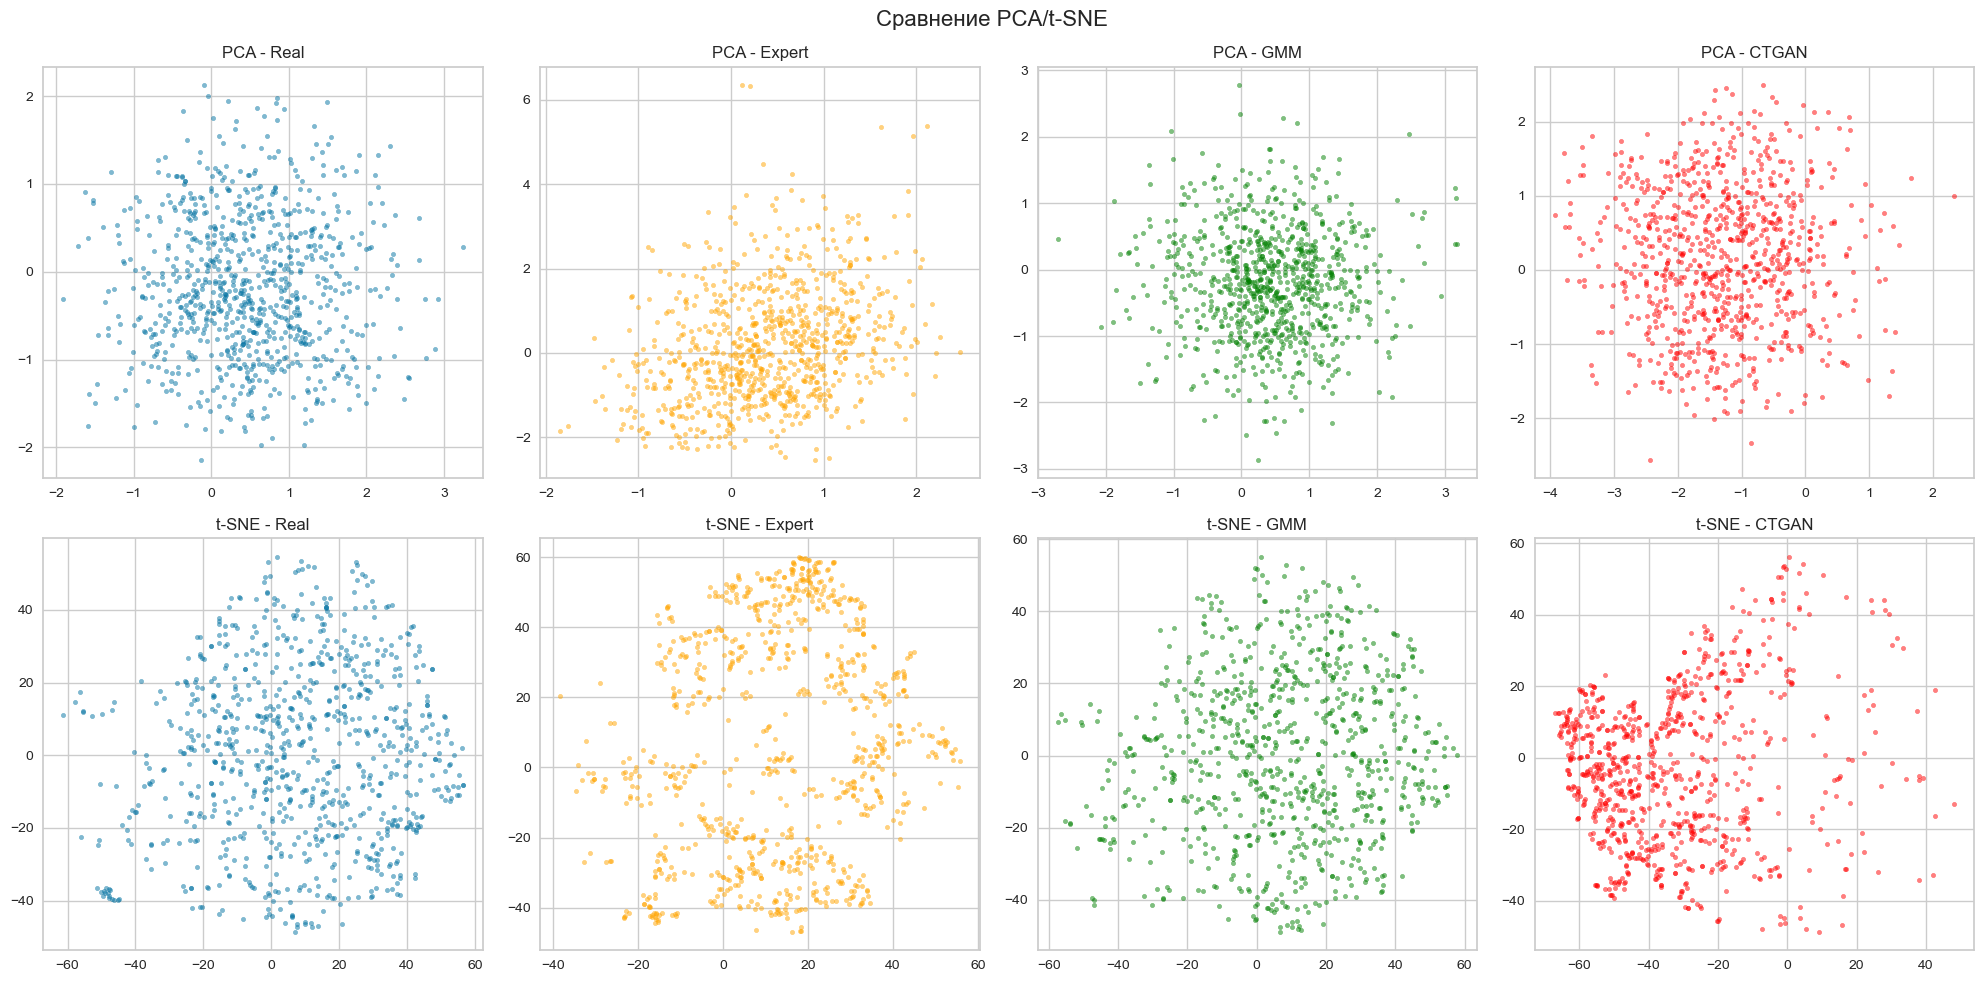

In [42]:
def plot_pca_tsne(real, expert, gmm, ctgan, num_cols, title_prefix=""):
    real_num = real[num_cols].copy()
    expert_num = expert[num_cols].copy()
    gmm_num = gmm[num_cols].copy()
    ctgan_num = ctgan[num_cols].copy()
    all_data = pd.concat([real_num, expert_num, gmm_num, ctgan_num], axis=0)
    scaler2 = StandardScaler()
    all_scaled = scaler2.fit_transform(all_data)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(all_scaled)
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_result = tsne.fit_transform(all_scaled)
    n_real = len(real_num)
    n_expert = len(expert_num)
    n_gmm = len(gmm_num)
    n_ctgan = len(ctgan_num)
    pca_real = pca_result[:n_real]
    pca_expert = pca_result[n_real:n_real+n_expert]
    pca_gmm = pca_result[n_real+n_expert:n_real+n_expert+n_gmm]
    pca_ctgan = pca_result[-n_ctgan:]
    tsne_real = tsne_result[:n_real]
    tsne_expert = tsne_result[n_real:n_real+n_expert]
    tsne_gmm = tsne_result[n_real+n_expert:n_real+n_expert+n_gmm]
    tsne_ctgan = tsne_result[-n_ctgan:]
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes[0,0].scatter(pca_real[:,0], pca_real[:,1], alpha=0.5, s=10, label='Real')
    axes[0,0].set_title('PCA - Real')
    axes[0,1].scatter(pca_expert[:,0], pca_expert[:,1], alpha=0.5, s=10, color='orange', label='Expert')
    axes[0,1].set_title('PCA - Expert')
    axes[0,2].scatter(pca_gmm[:,0], pca_gmm[:,1], alpha=0.5, s=10, color='green', label='GMM')
    axes[0,2].set_title('PCA - GMM')
    axes[0,3].scatter(pca_ctgan[:,0], pca_ctgan[:,1], alpha=0.5, s=10, color='red', label='CTGAN')
    axes[0,3].set_title('PCA - CTGAN')
    axes[1,0].scatter(tsne_real[:,0], tsne_real[:,1], alpha=0.5, s=10)
    axes[1,0].set_title('t-SNE - Real')
    axes[1,1].scatter(tsne_expert[:,0], tsne_expert[:,1], alpha=0.5, s=10, color='orange')
    axes[1,1].set_title('t-SNE - Expert')
    axes[1,2].scatter(tsne_gmm[:,0], tsne_gmm[:,1], alpha=0.5, s=10, color='green')
    axes[1,2].set_title('t-SNE - GMM')
    axes[1,3].scatter(tsne_ctgan[:,0], tsne_ctgan[:,1], alpha=0.5, s=10, color='red')
    axes[1,3].set_title('t-SNE - CTGAN')
    plt.suptitle(title_prefix, fontsize=16)
    plt.tight_layout()
    plt.show()
plot_pca_tsne(df_clean, df_expert, df_gmm, df_ctgan, num_cols, title_prefix="Сравнение PCA/t-SNE")

### КОРРЕЛЯЦИОННЫЕ МАТРИЦЫ

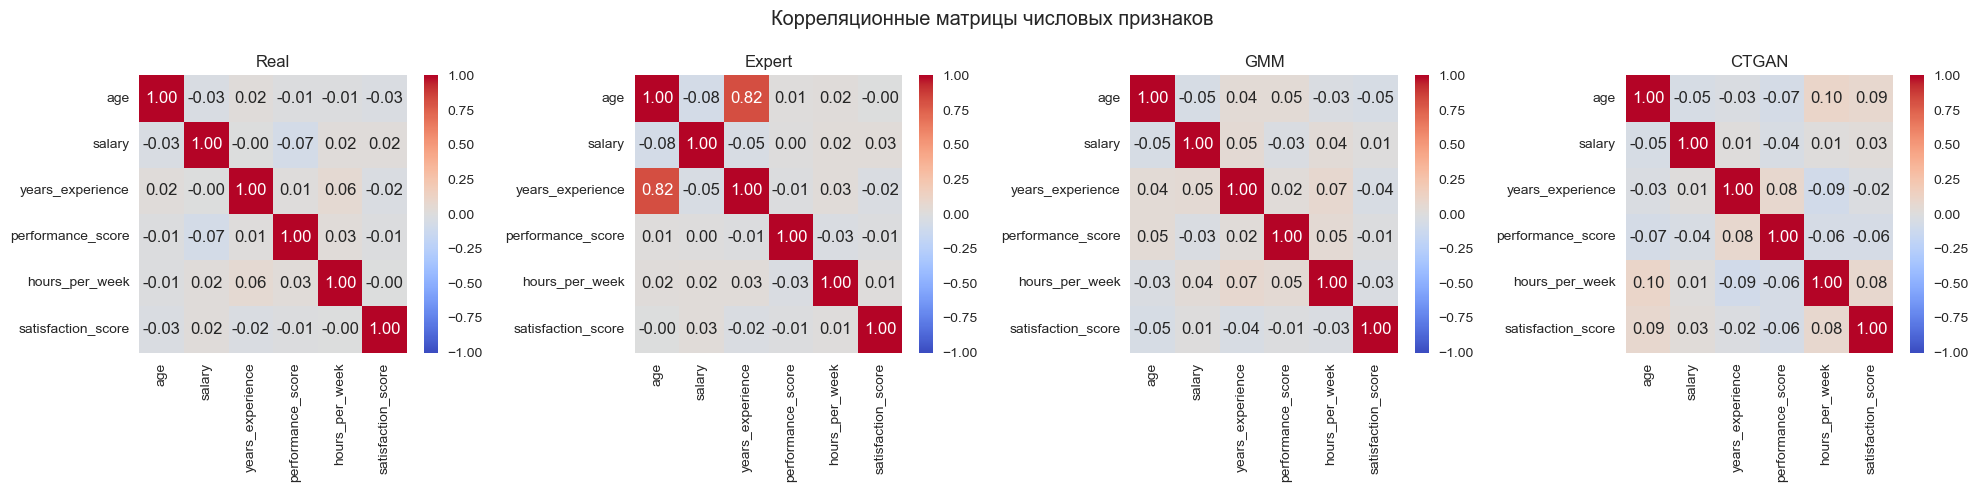

In [43]:
def plot_correlation_matrices(real, expert, gmm, ctgan, num_cols):
    corr_real = real[num_cols].corr()
    corr_expert = expert[num_cols].corr()
    corr_gmm = gmm[num_cols].corr()
    corr_ctgan = ctgan[num_cols].corr()
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    sns.heatmap(corr_real, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
    axes[0].set_title('Real')
    sns.heatmap(corr_expert, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
    axes[1].set_title('Expert')
    sns.heatmap(corr_gmm, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2], vmin=-1, vmax=1)
    axes[2].set_title('GMM')
    sns.heatmap(corr_ctgan, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[3], vmin=-1, vmax=1)
    axes[3].set_title('CTGAN')
    plt.suptitle("Корреляционные матрицы числовых признаков")
    plt.tight_layout()
    plt.show()
plot_correlation_matrices(df_clean, df_expert, df_gmm, df_ctgan, num_cols)

### ПАРНЫЕ ГРАФИКИ ЗАВИСИМОСТЕЙ

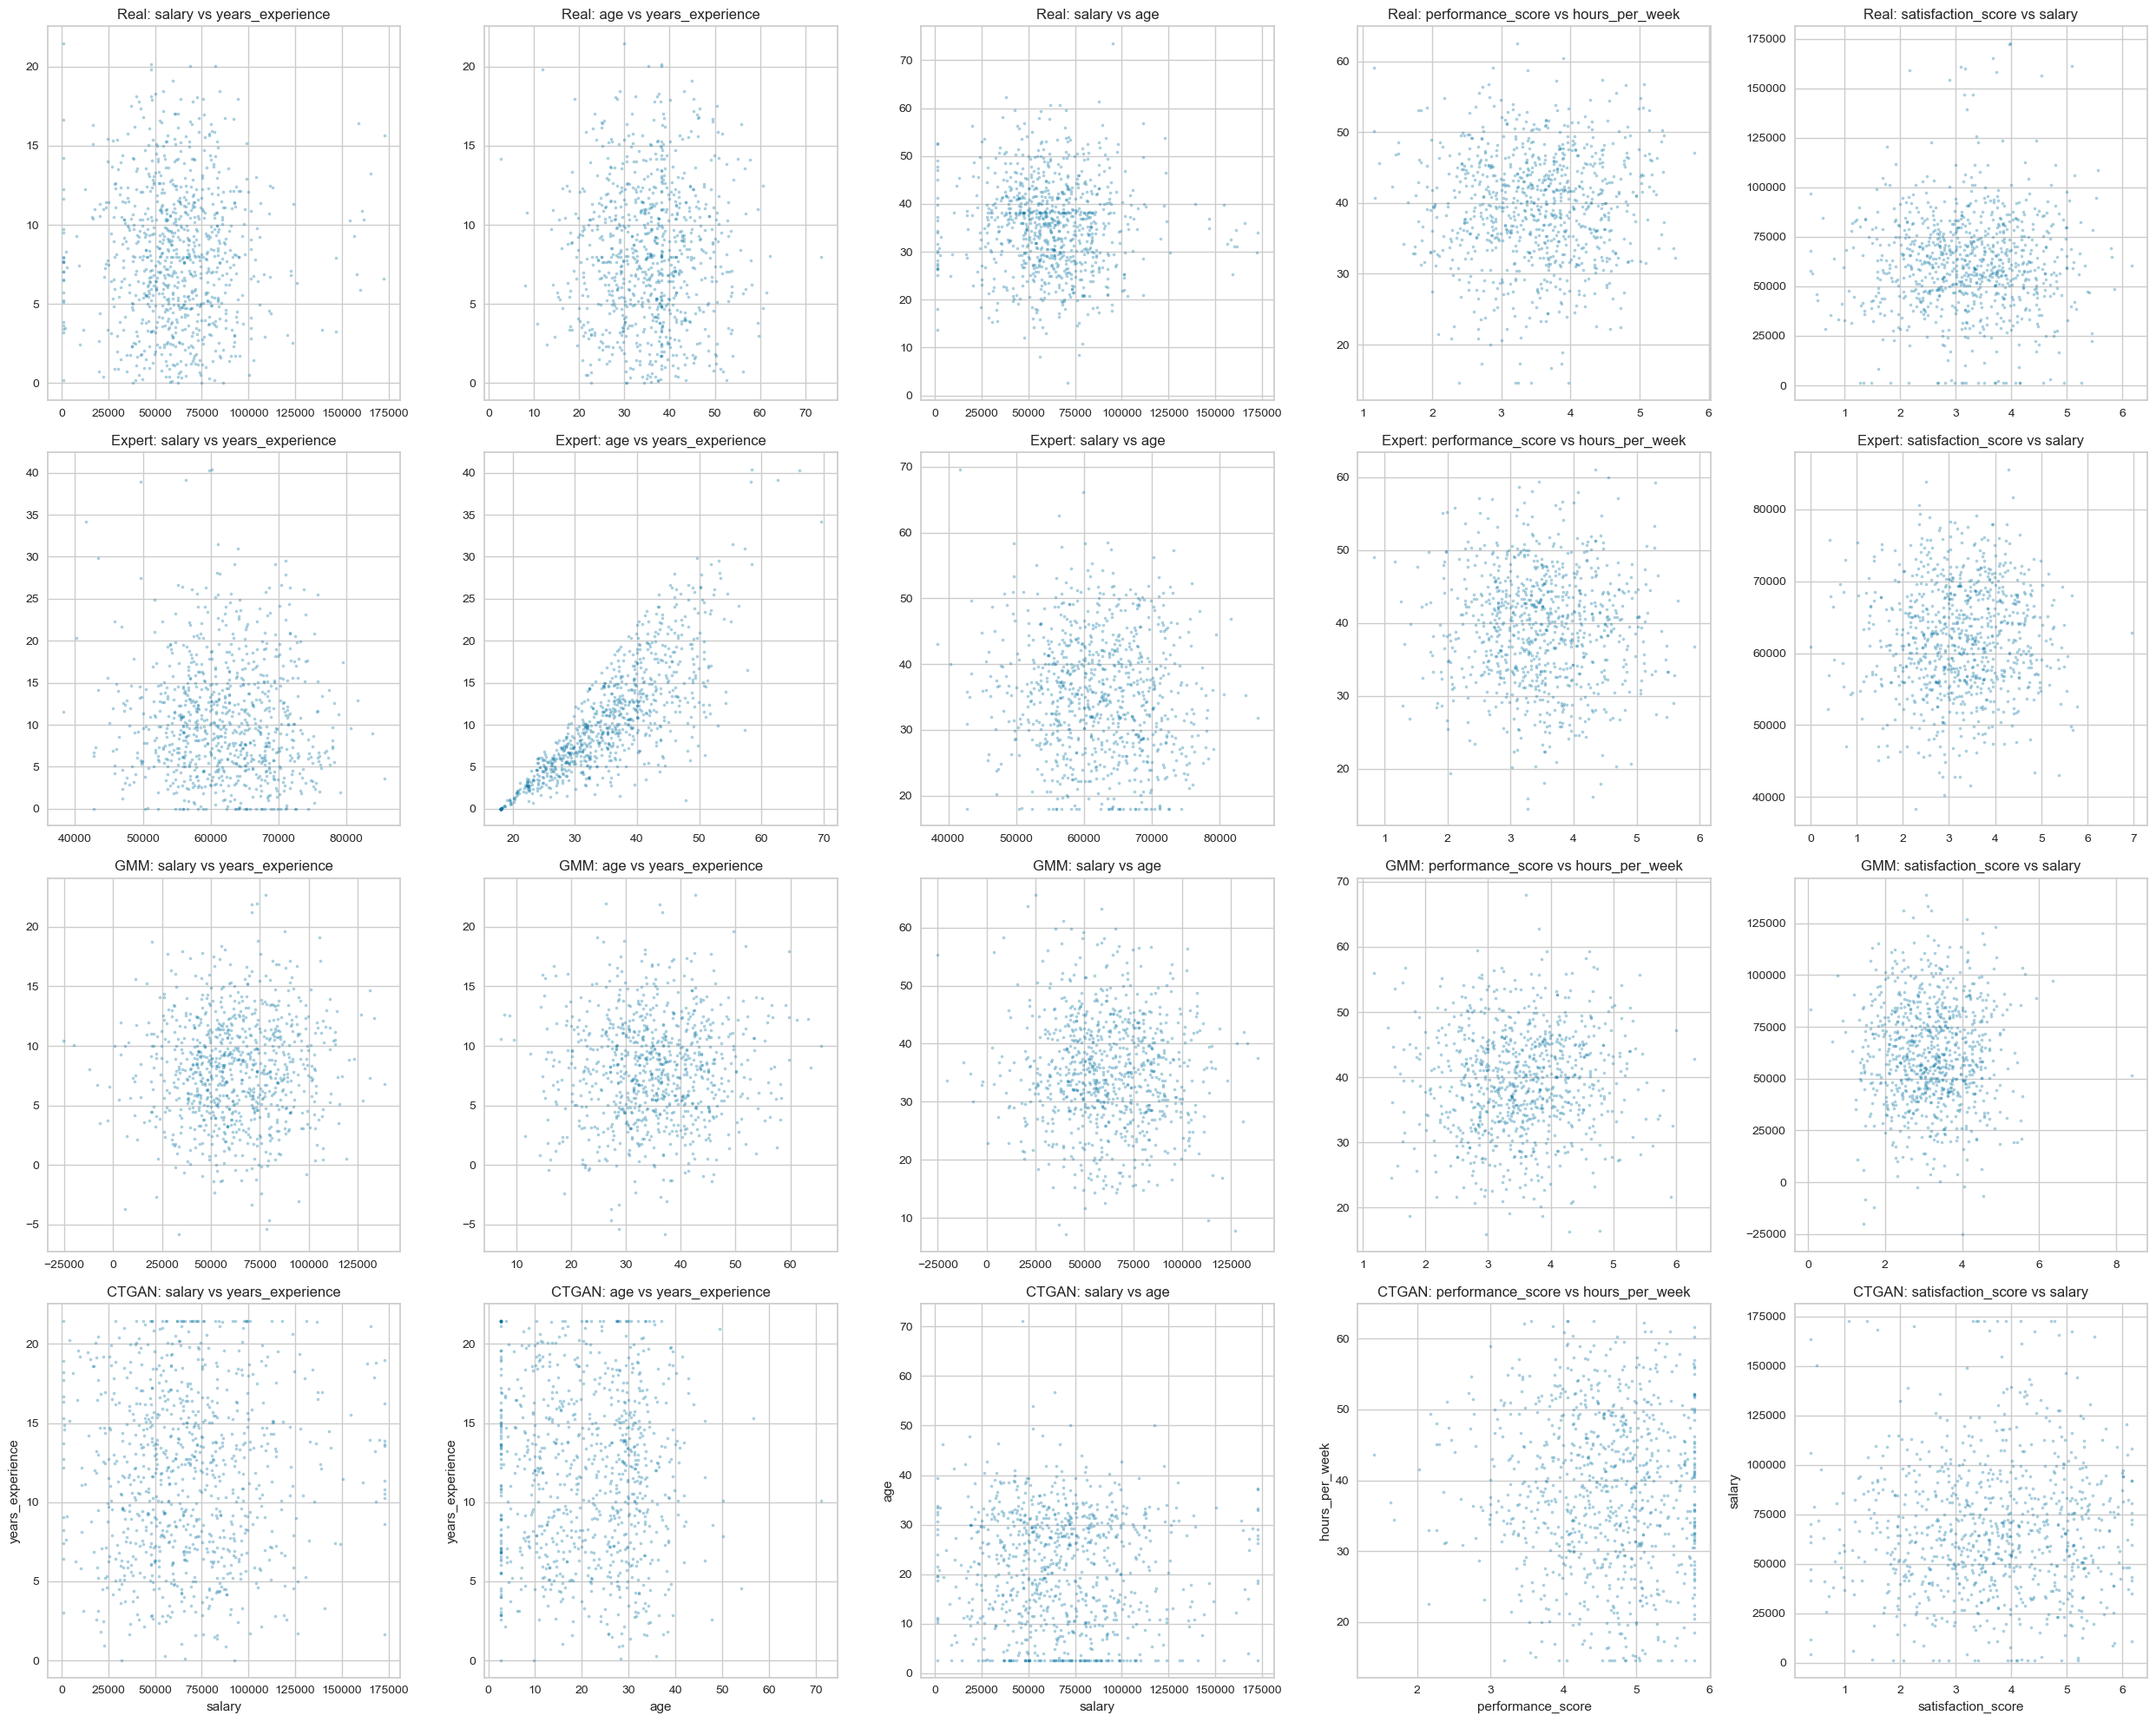

In [44]:
def plot_pairplots(real, expert, gmm, ctgan, num_cols):
    pairs = [('salary', 'years_experience'), ('age', 'years_experience'), ('salary', 'age'), ('performance_score', 'hours_per_week'), ('satisfaction_score', 'salary')]
    fig, axes = plt.subplots(4, 5, figsize=(25, 20))
    datasets = [('Real', real), ('Expert', expert), ('GMM', gmm), ('CTGAN', ctgan)]
    for i, (name, df) in enumerate(datasets):
        for j, (x, y) in enumerate(pairs):
            ax = axes[i, j]
            ax.scatter(df[x], df[y], alpha=0.3, s=5)
            ax.set_title(f"{name}: {x} vs {y}")
            if i == 3:
                ax.set_xlabel(x)
                ax.set_ylabel(y)
    plt.tight_layout()
    plt.show()
plot_pairplots(df_clean, df_expert, df_gmm, df_ctgan, num_cols)

### СТАТИСТИКИ (МОДА, МЕДИАНА, СРЕДНЕЕ)


СРАВНИТЕЛЬНАЯ СТАТИСТИКА

--- age ---
Real   : mean=35.46, median=35.92, mode=38.23
Expert : mean=35.24, median=35.34, mode=18.00
GMM    : mean=35.10, median=34.93, mode=7.10
CTGAN  : mean=21.09, median=22.10, mode=2.59

--- salary ---
Real   : mean=61795.88, median=60926.72, mode=1192.23
Expert : mean=62070.79, median=62029.44, mode=38340.96
GMM    : mean=61846.16, median=60536.49, mode=-25315.34
CTGAN  : mean=67686.08, median=65045.78, mode=1192.23

--- years_experience ---
Real   : mean=8.11, median=7.95, mode=7.95
Expert : mean=10.42, median=9.51, mode=0.00
GMM    : mean=8.05, median=8.06, mode=-5.84
CTGAN  : mean=11.72, median=11.83, mode=21.47

--- performance_score ---
Real   : mean=3.50, median=3.53, mode=1.16
Expert : mean=3.48, median=3.45, mode=0.83
GMM    : mean=3.52, median=3.51, mode=1.18
CTGAN  : mean=4.53, median=4.61, mode=5.79

--- hours_per_week ---
Real   : mean=39.47, median=39.83, mode=14.59
Expert : mean=39.30, median=39.79, mode=14.53
GMM    : mean=39.37, media

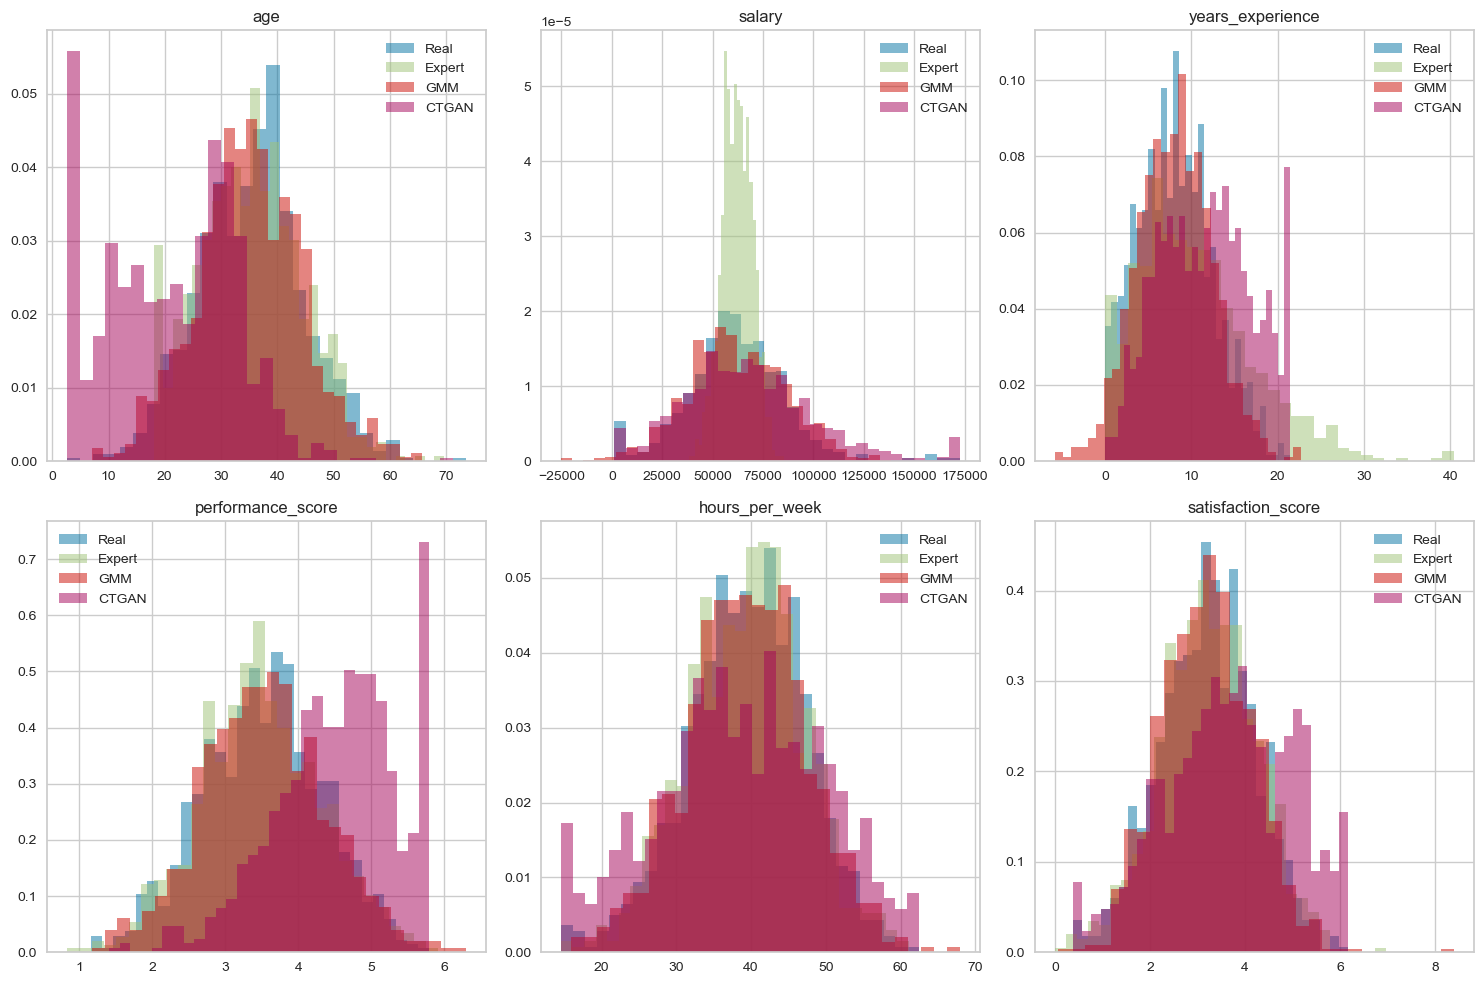

In [45]:
def compute_stats(df, name):
    stats_dict = {}
    for col in df.columns:
        if col in num_cols:
            stats_dict[col] = {
                'mean': df[col].mean(),
                'median': df[col].median(),
                'mode': df[col].mode()[0] if not df[col].mode().empty else np.nan
            }
        else:
            mode_val = df[col].mode()[0] if not df[col].mode().empty else np.nan
            mode_count = df[col].value_counts().iloc[0] if not df[col].value_counts().empty else 0
            stats_dict[col] = {
                'mode': mode_val,
                'frequency': mode_count,
                'unique_values': df[col].nunique()
            }
    return stats_dict
stats_real = compute_stats(df_clean, 'Real')
stats_expert = compute_stats(df_expert, 'Expert')
stats_gmm = compute_stats(df_gmm, 'GMM')
stats_ctgan = compute_stats(df_ctgan, 'CTGAN')
print("\nСРАВНИТЕЛЬНАЯ СТАТИСТИКА")
for col in df_clean.columns:
    print(f"\n--- {col} ---")
    if col in num_cols:
        print(f"Real   : mean={stats_real[col]['mean']:.2f}, median={stats_real[col]['median']:.2f}, mode={stats_real[col]['mode']:.2f}")
        print(f"Expert : mean={stats_expert[col]['mean']:.2f}, median={stats_expert[col]['median']:.2f}, mode={stats_expert[col]['mode']:.2f}")
        print(f"GMM    : mean={stats_gmm[col]['mean']:.2f}, median={stats_gmm[col]['median']:.2f}, mode={stats_gmm[col]['mode']:.2f}")
        print(f"CTGAN  : mean={stats_ctgan[col]['mean']:.2f}, median={stats_ctgan[col]['median']:.2f}, mode={stats_ctgan[col]['mode']:.2f}")
    else:
        print(f"Real   : mode={stats_real[col]['mode']}, freq={stats_real[col]['frequency']}/{len(df_clean)}")
        print(f"Expert : mode={stats_expert[col]['mode']}, freq={stats_expert[col]['frequency']}/{len(df_expert)}")
        print(f"GMM    : mode={stats_gmm[col]['mode']}, freq={stats_gmm[col]['frequency']}/{len(df_gmm)}")
        print(f"CTGAN  : mode={stats_ctgan[col]['mode']}, freq={stats_ctgan[col]['frequency']}/{len(df_ctgan)}")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, col in enumerate(num_cols):
    ax = axes[idx]
    ax.hist(df_clean[col], bins=30, alpha=0.5, label='Real', density=True)
    ax.hist(df_expert[col], bins=30, alpha=0.5, label='Expert', density=True)
    ax.hist(df_gmm[col], bins=30, alpha=0.5, label='GMM', density=True)
    ax.hist(df_ctgan[col], bins=30, alpha=0.5, label='CTGAN', density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [46]:
df_expert.to_csv('expert_gen_data.csv', index=False)

In [47]:
df_gmm.to_csv('gmm_gen_data.csv', index=False)

In [48]:
df_ctgan.to_csv('ctgan_gen_data.csv', index=False)